## Artificial Neural Networks --> From Data to Decision: Interpreting Neural Network Outputs

## 1. Project Title
A three-category classification task, where the model must predict whether a student will fall into one of the following classes: Dropout, Enrolled, or Graduate

## 2. Problem Statement & Business Goal

The dataset contains demographic, socioeconomic, application, enrollment, and
first- and second-semester academic-performance information for higher-education
students.

The objective is to develop a three-class artificial neural network that predicts
each student's recorded academic outcome as:

- Dropout
- Enrolled
- Graduate

Because the model uses first- and second-semester academic-performance variables,
it should be interpreted as an academic-outcome prediction model after early
course progress has been observed, rather than as a prediction made strictly at
the time of initial enrollment.

## 3. Dataset Details


### Demographics

| Column | Type | Description |
|---|---|---|
| `Marital status` | categorical (int) | 1=single, 2=married, 3=widower, 4=divorced, 5=facto union, 6=legally separated |
| `Nacionality` | categorical (int) | Coded nationality (1=Portuguese, plus ~20 other codes for other countries) |
| `Gender` | binary | 1=male, 0=female |
| `Age at enrollment` | numeric | Student's age when they enrolled |
| `International` | binary | 1 if classified as an international student, else 0 |
| `Displaced` | binary | 1 if the student is a displaced person (moved away from their permanent residence to attend), else 0 |
| `Educational special needs` | binary | 1 if the student has a declared special educational need, else 0 |

### Application & Enrollment

| Column | Type | Description |
|---|---|---|
| `Application mode` | categorical (int) | Coded admission pathway (general contingent, special contingents, transfers, over-23 admission, etc.) |
| `Application order` | numeric (0-9) | Preference rank of this course among the student's choices (0 = first choice, 9 = last) |
| `Course` | categorical (int) | Coded degree program (e.g. Nursing, Informatics Engineering, Management, Veterinary Nursing, etc.) |
| `Daytime/evening attendance` | binary | 1=daytime, 0=evening |
| `Previous qualification` | categorical (int) | Type of qualification held before enrolling (secondary education, various higher-ed levels, unfinished schooling, etc.) |
| `Previous qualification (grade)` | numeric (0-200) | Grade obtained in that previous qualification |
| `Admission grade` | numeric (0-200) | Grade used for admission into the course |

### Family Background

| Column | Type | Description |
|---|---|---|
| `Mother's qualification` | categorical (int) | Coded education level of the mother |
| `Father's qualification` | categorical (int) | Coded education level of the father |
| `Mother's occupation` | categorical (int) | Coded occupation category of the mother |
| `Father's occupation` | categorical (int) | Coded occupation category of the father |

### Financial Status

| Column | Type | Description |
|---|---|---|
| `Debtor` | binary | 1 if the student has outstanding debt to the institution, else 0 |
| `Tuition fees up to date` | binary | 1 if tuition payments are current, else 0 |
| `Scholarship holder` | binary | 1 if the student holds a scholarship, else 0 |

### First Semester Academic Performance

| Column | Type | Description |
|---|---|---|
| `Curricular units 1st sem (credited)` | numeric | Units credited (recognized from prior study) in semester 1 |
| `Curricular units 1st sem (enrolled)` | numeric | Units the student enrolled in for semester 1 |
| `Curricular units 1st sem (evaluations)` | numeric | Number of evaluations/exams taken in semester 1 |
| `Curricular units 1st sem (approved)` | numeric | Units passed in semester 1 |
| `Curricular units 1st sem (grade)` | numeric | Average grade across semester 1 units |
| `Curricular units 1st sem (without evaluations)` | numeric | Units with no evaluation recorded in semester 1 |

### Second Semester Academic Performance

| Column | Type | Description |
|---|---|---|
| `Curricular units 2nd sem (credited)` | numeric | Units credited in semester 2 |
| `Curricular units 2nd sem (enrolled)` | numeric | Units enrolled in for semester 2 |
| `Curricular units 2nd sem (evaluations)` | numeric | Number of evaluations/exams taken in semester 2 |
| `Curricular units 2nd sem (approved)` | numeric | Units passed in semester 2 |
| `Curricular units 2nd sem (grade)` | numeric | Average grade across semester 2 units |
| `Curricular units 2nd sem (without evaluations)` | numeric | Units with no evaluation recorded in semester 2 |

### Macroeconomic Context (at time of enrollment)

| Column | Type | Description |
|---|---|---|
| `Unemployment rate` | numeric (%) | National unemployment rate |
| `Inflation rate` | numeric (%) | National inflation rate |
| `GDP` | numeric | GDP growth indicator |

### Target

| Column | Type | Description |
|---|---|---|
| `Target` | categorical (string) | Outcome at end of the normal course duration: **Dropout** (left before completing), **Enrolled** (still enrolled past the normal end date), or **Graduate** (completed successfully) |

---



## 4. Import Required Libraries

NumPy is used for numerical operations and for implementing the neural network from scratch. Matplotlib is used to create exploratory and model-evaluation visualizations.

A fixed random seed is set to make random operations reproducible. This helps ensure that repeated executions of the notebook produce consistent results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 5. Load the Dataset

The dataset is downloaded from Google Drive using `gdown` and loaded into a pandas DataFrame.

The first five rows are displayed to verify that the file was downloaded and parsed correctly. This initial inspection also provides a quick view of the dataset structure, feature names, and target column.

In [2]:
!pip install -q gdown
import gdown

file_id = '1ZalCviXiAy9R91AR5fCYn53whjVMzBrL'
url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(url, 'ann-dataset.csv', quiet=False)

import pandas as pd
df = pd.read_csv('ann-dataset.csv')
df.head()


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
Downloading...
From: https://drive.google.com/uc?id=1ZalCviXiAy9R91AR5fCYn53whjVMzBrL
To: c:\Tannistha\BITS-Pilani-Materials\ANN\Graded Assignment\ann-dataset.csv
100%|██████████| 496k/496k [00:00<00:00, 2.88MB/s]


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 6. Inspect the Target Classes

The unique values in the `Target` column are examined to confirm the classification labels available in the dataset.

The problem is a three-class classification task with the following outcomes:

- **Dropout** — the student left the program before completion.
- **Enrolled** — the student remained enrolled beyond the normal course duration.
- **Graduate** — the student successfully completed the program.

In [3]:
df['Target'].unique()

<StringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str

## 7. Data Quality Assessment

The data types of all columns are inspected to distinguish numerical, binary, categorical-code, and target variables.

The dataset is also checked for missing values. Confirming the absence or presence of missing values is important because incomplete observations may require imputation, removal, or additional preprocessing before model training.



In [4]:
print(df.dtypes)
print()
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
if missing.sum() > 0:
    print(missing[missing > 0])

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

### Conclusion – Data Quality

The dataset contains complete observations with no missing values. The feature types are appropriate for further preprocessing, and the absence of missing data eliminates the need for imputation before model development.

## 8. Target-Class Distribution

The number and percentage of observations in each target class are calculated and visualized.

This step checks whether the target variable is balanced. An imbalanced dataset can cause a neural network to favor the majority class, so if imbalance is present, it needs to be addressed before modeling.


Target
Dropout     1421
Enrolled     794
Graduate    2209
Name: count, dtype: int64

Target
Dropout     32.1%
Enrolled    17.9%
Graduate    49.9%
Name: count, dtype: str


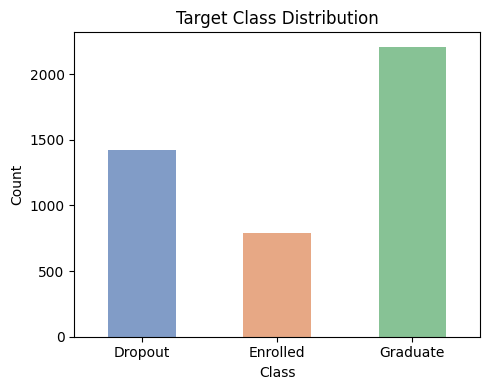

In [5]:
class_order = ["Dropout", "Enrolled", "Graduate"]

target_counts = df["Target"].value_counts().reindex(class_order)
print(target_counts)
print()
print((target_counts / len(df) * 100).round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.7)
ax.set_title("Target Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Conclusion – Target Distribution

The target classes are moderately imbalanced, with the **Graduate** class containing the largest number of observations and **Enrolled** the fewest.

## 9. Descriptive Statistics

Summary statistics are generated for the numerical variables, including count, mean, standard deviation, minimum, quartiles, and maximum.

This analysis helps identify:

- differences in feature scales;
- possible outliers;
- variables with limited variation;
- unusual minimum or maximum values;
- features that may require standardization.

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


### Conclusion – Descriptive Statistics

The numerical variables vary considerably in scale and range, indicating that feature standardization is necessary before training the neural network. No obvious data quality issues were identified from the summary statistics.

## 10. Demographic Characteristics and Student Outcomes

Selected demographic and personal characteristics are compared with the target outcome.

Stacked proportional bar charts are used for categorical and binary variables, while age distributions are shown using overlapping histograms. Normalizing the crosstabs by row shows the proportion of Dropout, Enrolled, and Graduate students within each category rather than only the raw number of students.

This analysis helps determine whether demographic characteristics show visible differences in academic outcomes.

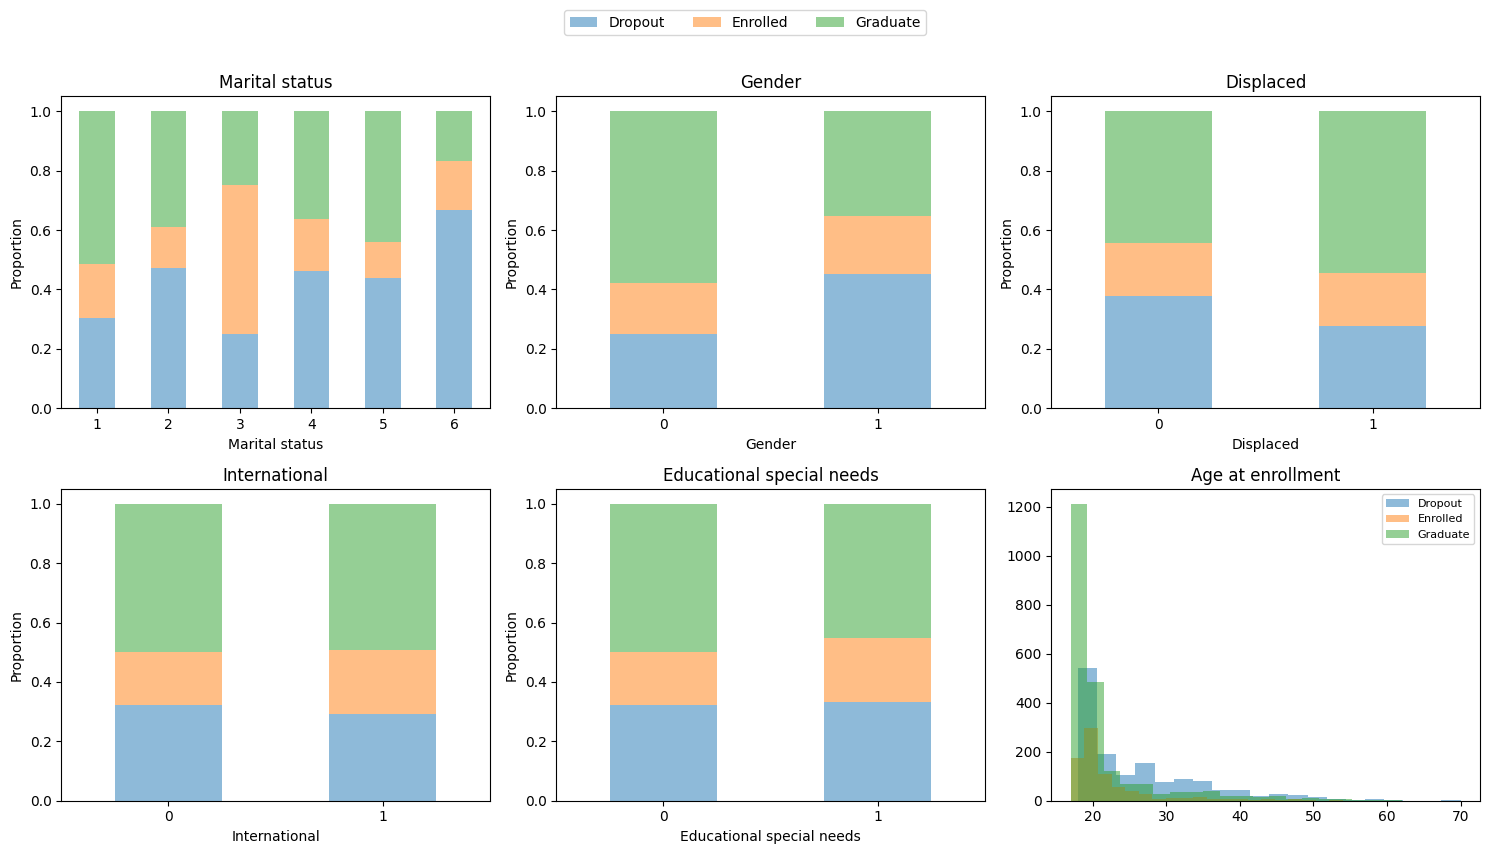

In [7]:
demo_categorical = ["Marital status", "Gender", "Displaced", "International", "Educational special needs"]
demo_numeric = ["Age at enrollment"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, demo_categorical):
    ct = pd.crosstab(df[col], df["Target"], normalize="index")
    ct = ct[class_order]  # enforce consistent column order
    ct.plot(kind="bar", stacked=True, ax=ax,  legend=False, alpha=0.5)
    ax.set_title(col)
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=0)

# Age distribution by target
ax = axes[5]
for target_class in class_order:
    subset = df.loc[df["Target"] == target_class, "Age at enrollment"]
    ax.hist(subset, bins=20, alpha=0.5, label=target_class)
ax.set_title("Age at enrollment")
ax.legend(fontsize=8)

axes[-1] if len(demo_categorical) < 6 else None
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.07))
plt.tight_layout()
plt.show()

### Conclusion – Demographic Analysis

Most demographic variables show only modest differences across the three student outcomes, but a couple of patterns stand out:

1. **Marital status** — students who are legally separated (category 6) show a notably higher dropout rate, likely reflecting the added financial and family pressures that come.
2. **Age** — older students tend to drop out more often, again pointing to competing financial and family obligations outside of school.


## 11. Financial Characteristics and Student Outcomes

The relationships between financial indicators and student outcomes are examined.

The analysis includes:

- debtor status;
- whether tuition fees are up to date;
- scholarship-holder status.

Stacked proportional bar charts and normalized crosstab values are used to compare outcome distributions across each financial category. These variables may provide useful predictive information because financial difficulty can affect program completion.

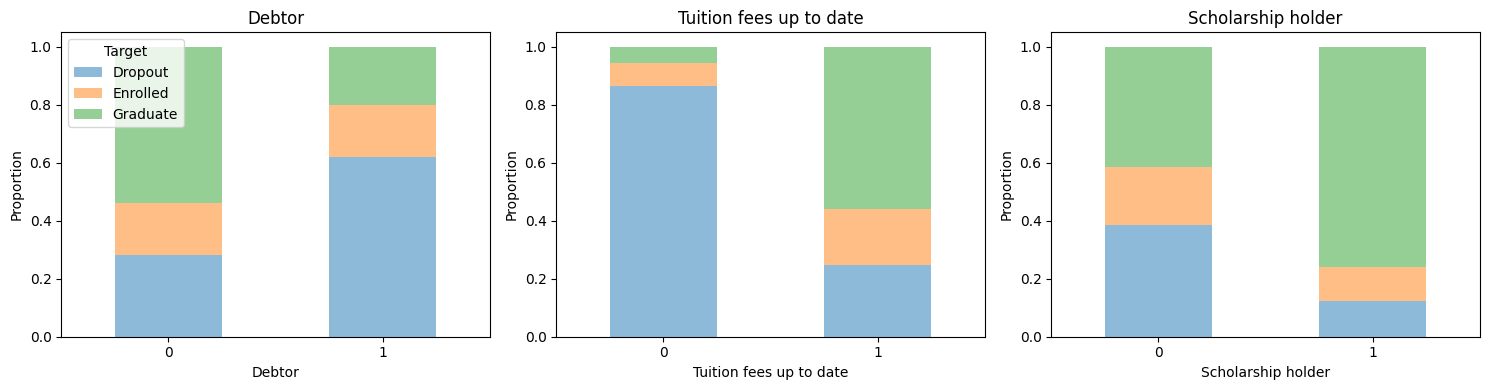


Debtor:
Target  Dropout  Enrolled  Graduate
Debtor                             
0         0.283     0.180     0.538
1         0.620     0.179     0.201

Tuition fees up to date:
Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
0                          0.866     0.080     0.055
1                          0.247     0.193     0.560

Scholarship holder:
Target              Dropout  Enrolled  Graduate
Scholarship holder                             
0                     0.387     0.200     0.413
1                     0.122     0.118     0.760


In [8]:
financial_cols = ["Debtor", "Tuition fees up to date", "Scholarship holder"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, financial_cols):
    ct = pd.crosstab(df[col], df["Target"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax,  legend=(ax == axes[0]), alpha=0.5)
    ct = ct[class_order]
    ax.set_title(col)
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Quick numeric check: dropout rate by financial flag
for col in financial_cols:
    print(f"\n{col}:")
    print(pd.crosstab(df[col], df["Target"], normalize="index").round(3))

### Conclusion – Financial Analysis

Financial characteristics demonstrate a stronger relationship with student outcomes than many demographic variables. Students with overdue tuition fees or debtor status show a higher proportion of dropout cases, while scholarship holders exhibit higher graduation rates.

# 12. Academic Performance Analysis

Boxplots are used to compare first- and second-semester grades and enrollment levels across the three target classes.

The plots allow comparison of:

- median values;
- interquartile ranges;
- class overlap;
- extreme observations;
- zero-grade concentrations.

This analysis evaluates whether academic performance and course load differ meaningfully among Dropout, Enrolled, and Graduate students.

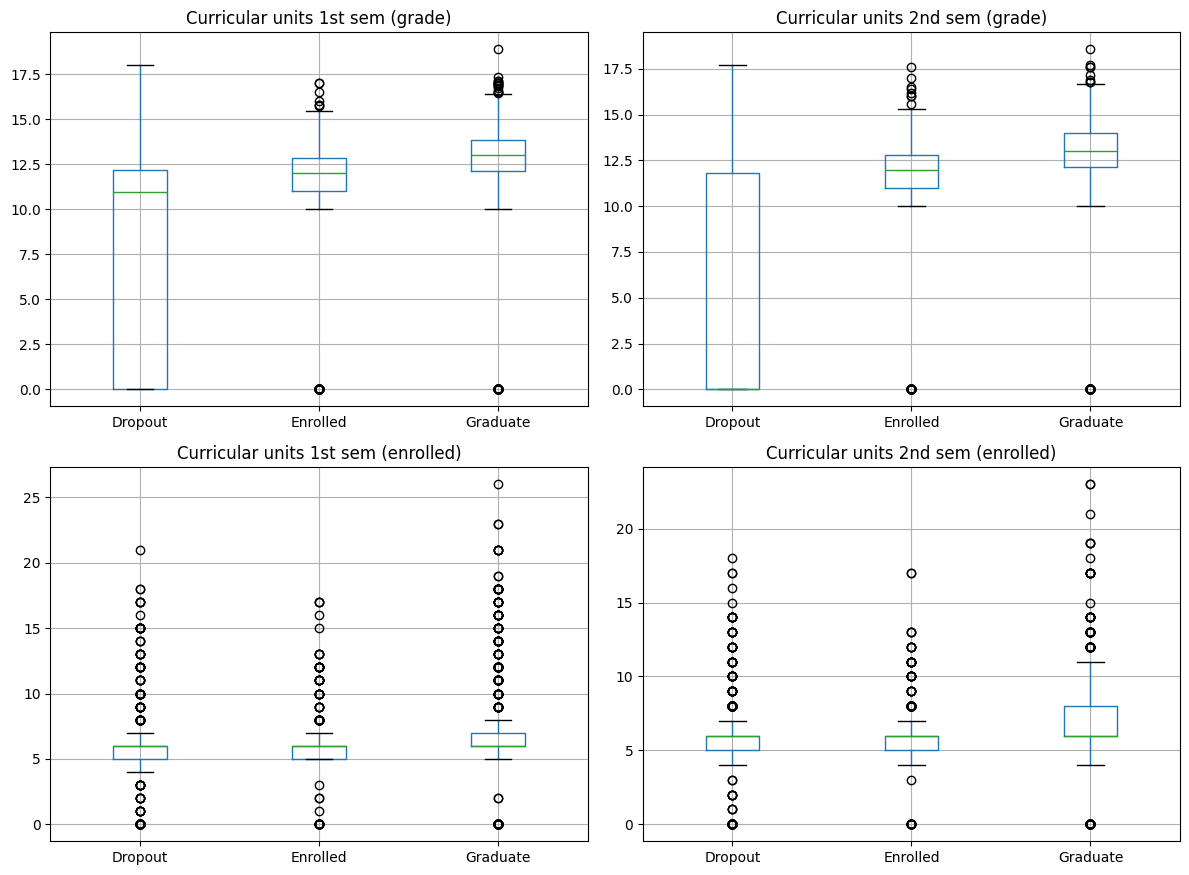

In [9]:
perf_cols = [
    "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)",
    "Curricular units 1st sem (enrolled)", "Curricular units 2nd sem (enrolled)",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, perf_cols):
    df.boxplot(column=col, by="Target", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()



### Conclusion – Academic Performance Analysis

Academic performance variables provide the clearest separation among the three target classes. Semester grades show a strong relationship with final academic outcome, making them highly informative features for the neural network.

## 13. Application, Previous Qualification, and Course Analysis

Application-related categorical variables are compared with student outcomes using normalized stacked bar charts.

The analysis examines:

- daytime or evening attendance;
- previous qualification;
- the ten most common courses.

Each bar represents the distribution of target outcomes within a category. This makes it possible to identify application pathways, prior qualifications, or courses associated with relatively higher proportions of Dropout, Enrolled, or Graduate students.

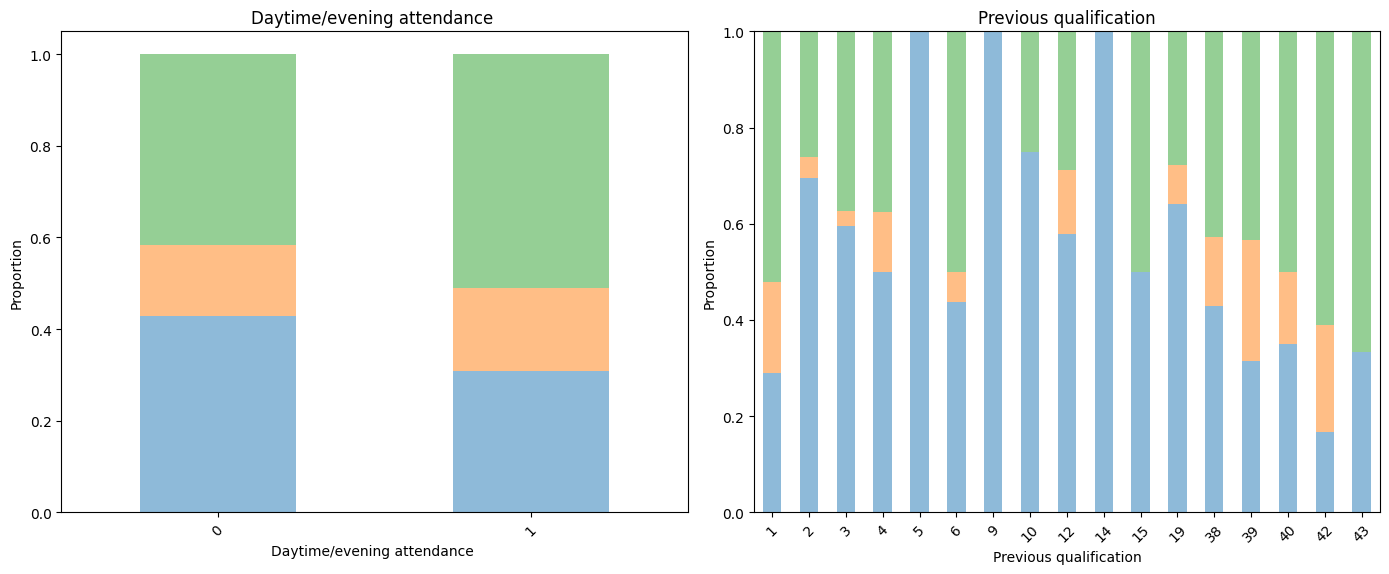

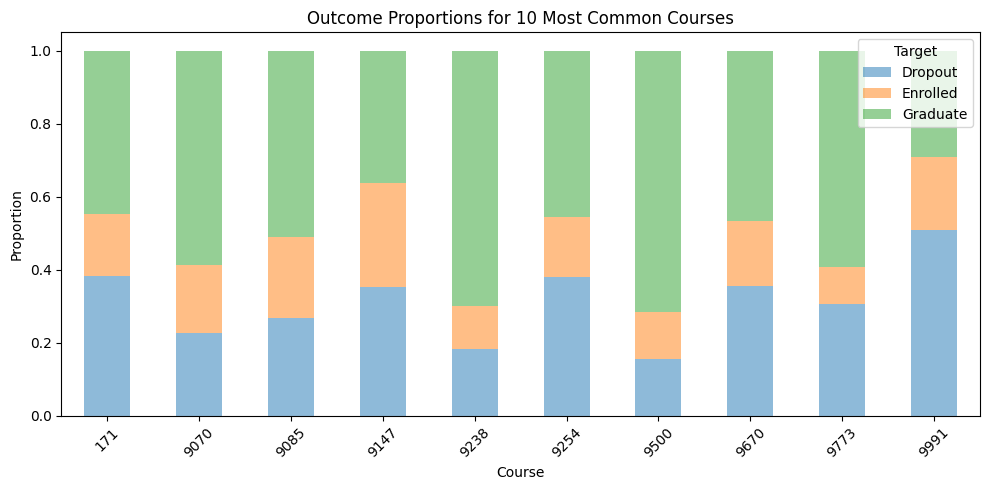

In [10]:
app_categorical = ["Daytime/evening attendance ", "Previous qualification"]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.ravel()

for ax, col in zip(axes[:2], app_categorical):
    ct = pd.crosstab(df[col], df["Target"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax, alpha=0.5, legend=False)
    ax.set_title(col)
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=45)



plt.suptitle("")
plt.tight_layout()
plt.show()

# Top 10 most common courses by target outcome
top_courses = df["Course"].value_counts().head(10).index
course_ct = pd.crosstab(df[df["Course"].isin(top_courses)]["Course"], df["Target"], normalize="index")
course_ct.plot(kind="bar", stacked=True, figsize=(10, 5), alpha=0.5)
plt.title("Outcome Proportions for 10 Most Common Courses")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion – Previous Qualification Analysis

Most previous qualification categories show broadly similar outcome distributions. A few rare categories, however, contain students from only a single class — these should be treated with caution and validated against the actual student count in each bin before drawing conclusions from them.

Course selection and day/evening attendance do not show any significant patterns.

## 14. Frequency of Previous-Qualification Categories

Following our previous observation on previous-qualification categories, the frequency of each `Previous qualification` category is examined before encoding.

Some qualification codes occur very rarely. Directly one-hot encoding these categories would create sparse dummy variables containing very few positive observations.

In [11]:
df["Previous qualification"].value_counts()

Previous qualification
1     3717
39     219
19     162
3      126
12      45
40      40
42      36
2       23
6       16
9       11
4        8
38       7
43       6
10       4
15       2
5        1
14       1
Name: count, dtype: int64

## 15. Group Rare Previous-Qualification Categories

Rare values in `Previous qualification` are grouped into a common `Other` category.

Grouping infrequent categories:

- reduces the number of sparse dummy variables;
- improves the stability of one-hot-encoded features;
- prevents the model from learning patterns from categories represented by very few observations;


The column is converted to string type before introducing the text category `Other`, ensuring that all values have a consistent data type.

In [12]:
# ---------------------------------------------------------
# Group rare Previous qualification categories
# ---------------------------------------------------------

# Count each category
qualification_counts = df["Previous qualification"].value_counts()

# Categories occurring fewer than 50 times
rare_qualifications = qualification_counts[
    qualification_counts < 50
].index

# Convert only this column to string
df["Previous qualification"] = (
    df["Previous qualification"]
    .astype(str)
)

# Group rare values under Other
df.loc[
    df["Previous qualification"].isin(
        rare_qualifications.astype(str)
    ),
    "Previous qualification"
] = "Other"

## 16. Verify Rare-Category Grouping

The updated value counts are displayed after grouping rare qualification categories.

This validation confirms that the original low-frequency qualification codes have been replaced by `Other` and that the more frequent categories remain unchanged.

In [13]:
df["Previous qualification"].value_counts()

Previous qualification
1        3717
39        219
Other     200
19        162
3         126
Name: count, dtype: int64

## 17. Student Outcomes by Grouped Previous Qualification

The distribution of student outcomes is visualized for each grouped previous-qualification category.

The crosstab is normalized by qualification category, so every bar represents the proportion of Dropout, Enrolled, and Graduate students within that qualification group.

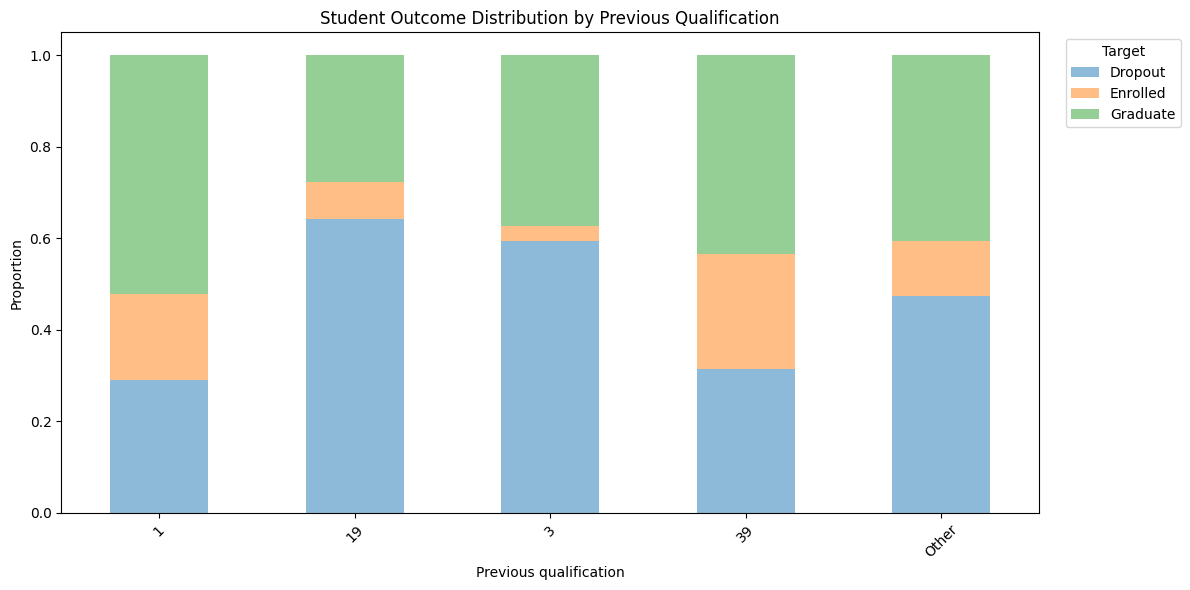

In [14]:
app_categorical = "Previous qualification"

ct = pd.crosstab(
    df[app_categorical],
    df["Target"],
    normalize="index"
)

# Ensure consistent target-class order
ct = ct.reindex(
    columns=class_order,
    fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 6))

ct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    alpha=0.5
)

ax.set_title(
    "Student Outcome Distribution by Previous Qualification"
)
ax.set_xlabel("Previous qualification")
ax.set_ylabel("Proportion")
ax.tick_params(axis="x", rotation=45)
ax.legend(
    title="Target",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Conclusion – Previous Qualification Analysis (after grouping)

Grouping gives a clearer picture of the data distribution. Previous qualification code 19 — "Basic education 3rd cycle (9th/10th/11th year) or equivalent" — shows a higher dropout rate, which aligns with the general expectation that a stronger academic foundation is needed to succeed in higher education.



## 18. Correlation Among Numeric and Binary Features

A Pearson correlation heatmap is generated for continuous, count, and binary variables.

Integer-coded nominal variables are excluded because their numeric codes represent category identifiers rather than meaningful quantitative distances. Calculating Pearson correlation on such codes could produce misleading relationships.

The heatmap helps identify strongly related numerical variables and possible redundancy before engineered ratio features are added.

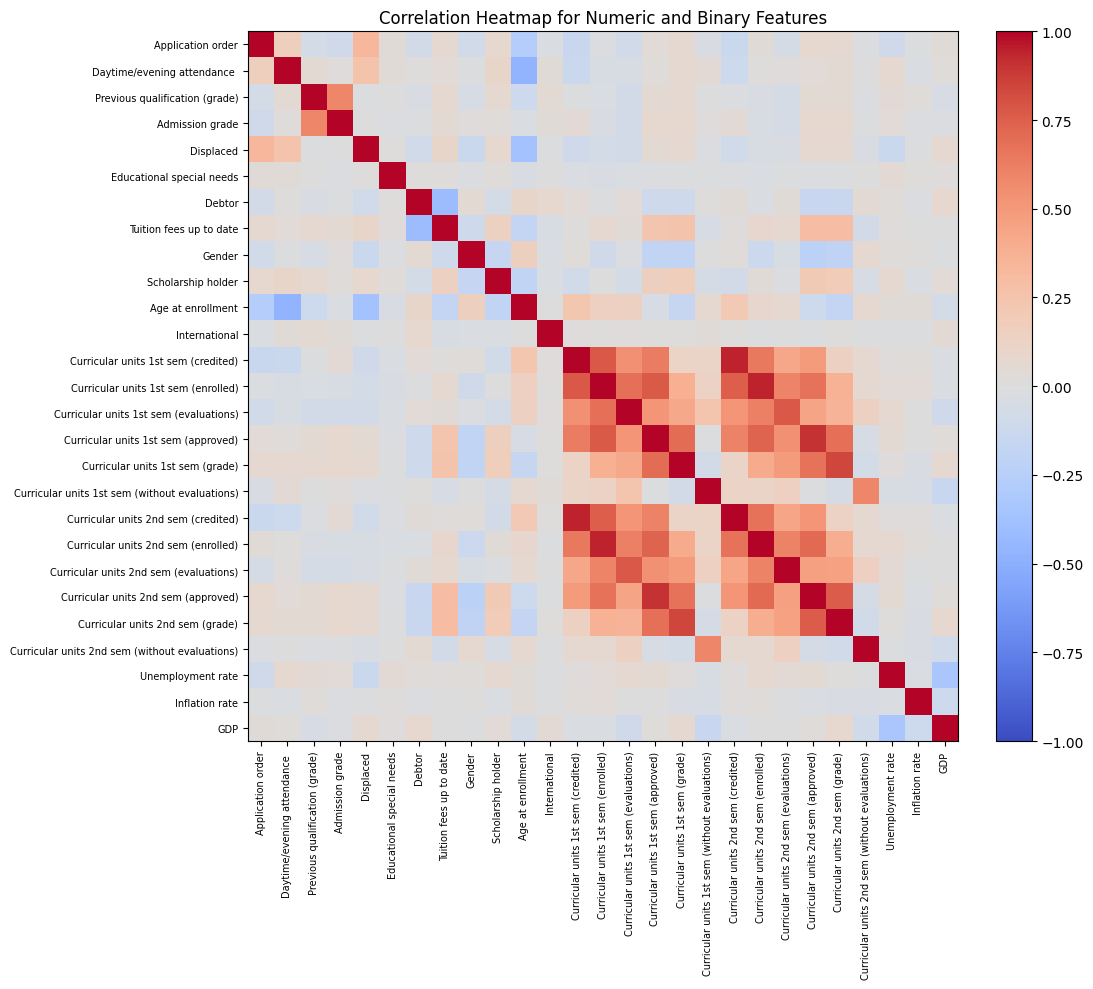

In [15]:
categorical_code_columns = [
    "Marital status",
    "Application mode",
    "Course",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
]

correlation_df = df.drop(columns=["Target"] + categorical_code_columns, errors="ignore")

corr = correlation_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))

image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)

ax.set_yticklabels(corr.columns, fontsize=7)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

ax.set_title("Correlation Heatmap for Numeric and Binary Features")

plt.tight_layout()
plt.show()


### Conclusion – Correlation Analysis

The correlation analysis indicates that several academic variables are related, while most demographic variables show relatively weak linear relationships.In general, neural networks are more robust to multicollinearity than traditional machine learning models.Activation functions allow networks to combine correlated inputs into rich, non-linear representations without breaking the training math.

We are generating some "academic-progress-ratio" data to improve performance and faster convergence.

## 19. Engineer Academic Progress Ratios

Four ratio-based academic-performance features are created:

- first-semester approval rate;
- first-semester evaluations per enrolled unit;
- second-semester approval rate;
- second-semester evaluations per enrolled unit.

Approval rate measures the proportion of enrolled units successfully completed. Evaluations per enrolled unit measures the amount of evaluation activity relative to course enrollment.

When the number of enrolled units is zero, the denominator is temporarily replaced with `NaN` to avoid division by zero. The resulting undefined ratios are then set to zero.

The original approved and evaluation-count columns are removed because their information is represented relative to enrollment in the newly engineered features. The original enrollment-count columns are retained so the model can distinguish zero enrollment from enrollment with zero approvals.

In [16]:
def add_ratio_features(df):
    df = df.copy()

    # First-semester ratios
    df["1st sem approval rate"] = (
        df["Curricular units 1st sem (approved)"]
        / df["Curricular units 1st sem (enrolled)"].replace(0, np.nan)
    ).fillna(0)

    df["1st sem evaluations per enrolled unit"] = (
        df["Curricular units 1st sem (evaluations)"]
        / df["Curricular units 1st sem (enrolled)"].replace(0, np.nan)
    ).fillna(0)

    # Second-semester ratios
    df["2nd sem approval rate"] = (
        df["Curricular units 2nd sem (approved)"]
        / df["Curricular units 2nd sem (enrolled)"].replace(0, np.nan)
    ).fillna(0)

    df["2nd sem evaluations per enrolled unit"] = (
        df["Curricular units 2nd sem (evaluations)"]
        / df["Curricular units 2nd sem (enrolled)"].replace(0, np.nan)
    ).fillna(0)

    columns_to_drop = [
        "Curricular units 1st sem (evaluations)",
        "Curricular units 1st sem (approved)",
        "Curricular units 2nd sem (evaluations)",
        "Curricular units 2nd sem (approved)",
    ]

    return df.drop(columns=columns_to_drop)

df = add_ratio_features(df)

### Conclusion – Feature Engineering

The engineered approval-rate and evaluation-per-enrolled-unit features provide more meaningful measures of academic progress than the original raw counts.

- **First-semester approval rate** measures the proportion of enrolled courses that were successfully completed during the first semester.
- **First-semester evaluations per enrolled unit** measures the average number of academic evaluations completed for each enrolled course, reflecting academic participation.
- **Second-semester approval rate** measures the proportion of successfully completed courses during the second semester.
- **Second-semester evaluations per enrolled unit** measures the average number of evaluations completed per enrolled course during the second semester.

1. A higher approval rate generally indicates stronger academic performance.
2. A higher evaluations per unit values indicate greater participation in assessments.




## 20. Distribution of Engineered Academic Ratios

Overlapping histograms compare the distributions of the engineered ratio features across the three target classes.

These plots help determine whether approval rates and evaluation activity provide better class separation than the original raw counts.

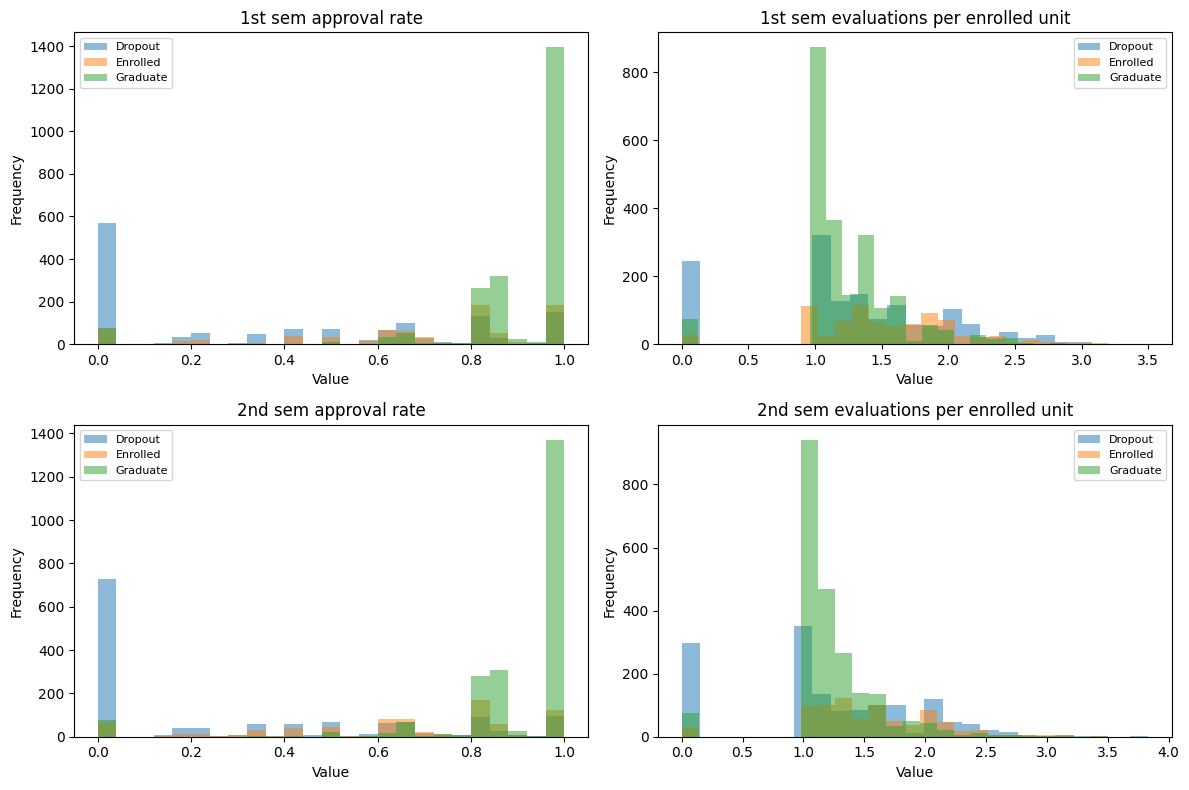

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

ratio_cols = [
    "1st sem approval rate",
    "1st sem evaluations per enrolled unit",
    "2nd sem approval rate",
    "2nd sem evaluations per enrolled unit",
]

plot_class_order = ["Dropout", "Enrolled", "Graduate"]

for ax, column in zip(axes, ratio_cols):

    for target_class in plot_class_order:

        subset = df.loc[df["Target"] == target_class, column]

        ax.hist(subset, bins=25, alpha=0.5, label=target_class)

    ax.set_title(column)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Interpretation of the Engineered Curriculum Features

The engineered curriculum features provide clearer separation among the three target classes than the original raw course counts.

The **first- and second-semester approval rates** show the strongest discrimination. Graduate students are heavily concentrated near an approval rate of 1.0, indicating that they successfully completed most of their enrolled courses. In contrast, many Dropout students have approval rates close to 0, suggesting that they passed few or none of their enrolled courses. Enrolled students generally fall between these two groups.

The **evaluations per enrolled unit** features measure academic participation rather than academic success. Graduate students tend to have consistent evaluation activity, while many Dropout students have very low values, indicating limited participation in assessments. Although these features show greater overlap among the classes than the approval rates, they still provide useful information about student engagement.




# 20. Prepare the Features and Target Variables

After completing feature engineering, the dataset is transformed into the numerical representation required for neural-network training.

This preprocessing stage performs the following tasks:

- separates predictor variables from the target variable;
- converts the three target classes into integer labels;
- identifies nominal categorical variables stored as numeric codes;
- applies one-hot encoding to the categorical variables;
- converts the processed DataFrame into a numerical feature matrix;
- stores feature names and class information for later interpretation.

These steps ensure that every input supplied to the neural network is numerical and suitable for matrix operations during forward and backward propagation.

In [18]:
# ---------------------------------------------------------
# Prepare features and target
# ---------------------------------------------------------

LABEL_MAP = {
    "Dropout": 0,
    "Enrolled": 1,
    "Graduate": 2
}

INVERSE_LABEL_MAP = {
    value: key for key, value in LABEL_MAP.items()
}

CLASS_NAMES = [
    INVERSE_LABEL_MAP[i]
    for i in range(len(LABEL_MAP))
]


def encode_labels(string_labels):
    """
    Convert string target labels into integer labels.
    """
    string_labels = np.asarray(string_labels)

    unknown_labels = set(string_labels) - set(LABEL_MAP)

    if unknown_labels:
        raise ValueError(
            f"Unrecognized labels found: {unknown_labels}"
        )

    return np.array(
        [LABEL_MAP[label] for label in string_labels],
        dtype=int
    )


# These columns contain category codes rather than continuous values
categorical_columns = [
    "Marital status",
    "Application mode",
    "Course",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]


categorical_columns = [
    column
    for column in categorical_columns
    if column in df.columns
]

# Separate predictors and target
X_df = df.drop(columns=["Target"]).copy()
y = encode_labels(df["Target"].values)

# One-hot encode nominal categorical columns
X_df = pd.get_dummies(
    X_df,
    columns=categorical_columns,
    drop_first=False,
    dtype=float
)

# Convert every feature to floating point
X = X_df.to_numpy(dtype=float)

FEATURE_NAMES = X_df.columns.tolist()

NUM_CLASSES = len(CLASS_NAMES)

print("Number of observations:", X.shape[0])
print("Number of features after encoding:", X.shape[1])
print("Target shape:", y.shape)
print("Class names:", CLASS_NAMES)
print("Class counts:", np.bincount(y, minlength=NUM_CLASSES))


Number of observations: 4424
Number of features after encoding: 235
Target shape: (4424,)
Class names: ['Dropout', 'Enrolled', 'Graduate']
Class counts: [1421  794 2209]


### Conclusion – Feature Encoding

Before the neural network can be trained, the dataset is converted into a numerical format suitable for matrix-based computations.

The target variable in the original dataset consists of three text labels:

- **Dropout**
- **Enrolled**
- **Graduate**

Neural networks cannot directly learn from text labels. Therefore, each class is mapped to a unique integer.

| Original Label | Encoded Value |
|---------------|--------------:|
| Dropout | 0 |
| Enrolled | 1 |
| Graduate | 2 |



Several variables in the dataset are stored as numeric values, but they actually represent **categories rather than continuous quantities**.

For example,

| Course Code | Meaning |
|-------------|---------|
| 33 | Nursing |
| 171 | Management |
| 9070 | Informatics |

Although these values are numeric, course **9070 is not "larger" or "better" than course 33**. They are simply identifiers.

The same applies to variables such as:

- Marital status
- Application mode
- Previous qualification
- Nationality
- Parents' qualifications
- Parents' occupations

Treating these variables as continuous numerical features would incorrectly imply mathematical relationships that do not exist.The categorical variables are converted into binary indicator variables using one-hot encoding.


After one-hot encoding, all variables are converted into floating-point numbers:
This creates the numerical feature matrix that will be used during forward propagation.


At the end of this preprocessing stage:

- the target labels have been converted into numerical class identifiers;
- categorical variables have been transformed into one-hot encoded binary features;
- predictors and target have been separated;
- all input features have been converted into floating-point values suitable for numerical computation;
- the feature matrix and target vector have been validated.

The processed feature matrix (`X`) and encoded target vector (`y`) are now ready for stratified train-validation-test splitting and subsequent neural network training.

## 21. Validate One-Hot-Encoded Features:

After one-hot encoding, the generated feature names are inspected to verify that all categorical variables have been transformed correctly.

This validation confirms:

- the number of encoded features;
- successful creation of dummy variables;
- correct grouping of the rare Previous Qualification categories into `Previous qualification_Other`;
- absence of unexpected standalone categories.

Performing this validation before model training helps identify preprocessing errors that could otherwise affect the neural network.

In [19]:
dummy_columns = [
    col for col in X_df.columns
    if any(
        col.startswith(cat + "_")
        for cat in categorical_columns
    )
]

print(f"Number of dummy columns: {len(dummy_columns)}")
print(dummy_columns)

Number of dummy columns: 208
['Marital status_1', 'Marital status_2', 'Marital status_3', 'Marital status_4', 'Marital status_5', 'Marital status_6', 'Application mode_1', 'Application mode_2', 'Application mode_5', 'Application mode_7', 'Application mode_10', 'Application mode_15', 'Application mode_16', 'Application mode_17', 'Application mode_18', 'Application mode_26', 'Application mode_27', 'Application mode_39', 'Application mode_42', 'Application mode_43', 'Application mode_44', 'Application mode_51', 'Application mode_53', 'Application mode_57', 'Course_33', 'Course_171', 'Course_8014', 'Course_9003', 'Course_9070', 'Course_9085', 'Course_9119', 'Course_9130', 'Course_9147', 'Course_9238', 'Course_9254', 'Course_9500', 'Course_9556', 'Course_9670', 'Course_9773', 'Course_9853', 'Course_9991', 'Previous qualification_1', 'Previous qualification_19', 'Previous qualification_3', 'Previous qualification_39', 'Previous qualification_Other', 'Nacionality_1', 'Nacionality_2', 'Naciona

## 22. Create Training, Validation, and Test Sets

The processed dataset is divided into three independent subsets using stratified sampling.

The split is approximately:

- 70% Training
- 15% Validation
- 15% Test

Stratification preserves the proportion of Dropout, Enrolled and Graduate students in every subset.

Each subset has a specific purpose:

- **Training set** – learns the model parameters.
- **Validation set** – compares different models and determines when to stop training.
- **Test set** – evaluates only the final selected model.

In [20]:
# ---------------------------------------------------------
# Create stratified train, validation and test sets
# ---------------------------------------------------------

from sklearn.model_selection import train_test_split

# First separate the final 15% test set
X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Separate approximately 15% validation data from the
# remaining 85% of the original data
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_val_raw,
    y_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_val
)

print("Training set:  ", X_train_raw.shape, y_train.shape)
print("Validation set:", X_val_raw.shape, y_val.shape)
print("Test set:      ", X_test_raw.shape, y_test.shape)

print("\nTraining class counts:")
print(np.bincount(y_train, minlength=NUM_CLASSES))

print("\nValidation class counts:")
print(np.bincount(y_val, minlength=NUM_CLASSES))

print("\nTest class counts:")
print(np.bincount(y_test, minlength=NUM_CLASSES))



Training set:   (3096, 235) (3096,)
Validation set: (664, 235) (664,)
Test set:       (664, 235) (664,)

Training class counts:
[ 995  556 1545]

Validation class counts:
[213 119 332]

Test class counts:
[213 119 332]


## 23. Standardize the Input Features

Neural networks are sensitive to differences in feature scale.

Features such as grades, age, approval rates and macroeconomic indicators have very different numerical ranges. If these variables are used directly, features with larger values can dominate the gradient updates.

To avoid this problem, every numerical feature is standardized using the training-set statistics.

The transformation is

$$
X_{scaled}
=
\frac{X-\mu_{train}}
{\sigma_{train}}
$$

where

- $\mu_{train}$ is the mean of the training feature.
- $\sigma_{train}$ is the standard deviation of the training feature.

The same statistics are then applied to the validation and test sets.

Using only training statistics prevents information leakage from the validation and test data.

**HIDDEN_SIZE=20** [Since this is a small dataset of around 3000 samples, we will have a small hidden layer of 20, so that it does not overfit]


In [21]:
# ---------------------------------------------------------
# Standardize features using training-set statistics only
# ---------------------------------------------------------

train_mean = X_train_raw.mean(axis=0)
train_std = X_train_raw.std(axis=0)

# Prevent division by zero for constant columns
train_std = np.where(train_std == 0, 1.0, train_std)

X_train = (X_train_raw - train_mean) / train_std
X_val = (X_val_raw - train_mean) / train_std
X_test = (X_test_raw - train_mean) / train_std

INPUT_SIZE = X_train.shape[1]
HIDDEN_SIZE = 20
NUM_CLASSES = len(CLASS_NAMES)

print("Input size:", INPUT_SIZE)
print("Hidden-layer size:", HIDDEN_SIZE)
print("Output size:", NUM_CLASSES)



Input size: 235
Hidden-layer size: 20
Output size: 3


## 24. Initialize Neural-Network Parameters

The neural network contains:

- one input layer,
- one hidden layer,
- one output layer.

The number of input neurons is determined automatically from the encoded feature matrix.

Initially, the hidden layer contains **20 neurons**. A smaller network containing **8 neurons** is evaluated later to determine whether comparable performance can be achieved using fewer parameters.

The output layer contains three neurons corresponding to:

- Dropout
- Enrolled
- Graduate

Weights are initialized using scaled random values, while all bias terms are initialized to zero.

In [22]:
# ---------------------------------------------------------
# Initialize neural-network weights and biases
# ---------------------------------------------------------

def init_params(
    input_size,
    hidden_size,
    output_size,
    seed=42
):

    rng = np.random.default_rng(seed)
    W1 = rng.normal(
        loc=0.0,
        scale=np.sqrt(1.0 / input_size),
        size=(input_size, hidden_size)
    )
    b1 = np.zeros((1, hidden_size))
    W2 = rng.normal(
        loc=0.0,
        scale=np.sqrt(1.0 / hidden_size),
        size=(hidden_size, output_size)
    )

    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2


## 25. Activation Functions and Forward Propagation

Forward propagation computes the prediction of the neural network.

The computation proceeds through the following stages.

1. Calculate the weighted input to the hidden layer.

$$
Z_1=XW_1+b_1
$$

2. Apply the hidden-layer activation function.

Initially, the hidden layer uses the Sigmoid activation function

$$
\sigma(z)=\frac1{1+e^{-z}}
$$

to introduce non-linearity.

3. Calculate the weighted input to the output layer.

$$
Z_2=A_1W_2+b_2
$$

4. Apply the Softmax activation function.

Softmax converts the output scores into probabilities for the three target classes.

Each probability represents the model's confidence that a student belongs to Dropout, Enrolled or Graduate.



In [23]:
# ---------------------------------------------------------
# Activation functions and forward propagation
# ---------------------------------------------------------

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))


def sigmoid_derivative(sigmoid_output):
    return sigmoid_output * (1.0 - sigmoid_output)


def softmax(x):
    shifted_x = x - np.max(
        x,
        axis=1,
        keepdims=True
    )
    exp_x = np.exp(shifted_x)
    return exp_x / np.sum(
        exp_x,
        axis=1,
        keepdims=True
    )


def forward(X, W1, b1, W2, b2):
     # Input to hidden layer
    z1 = X @ W1 + b1
    # Hidden-layer activation
    a1 = sigmoid(z1)
    # Hidden to output layer
    z2 = a1 @ W2 + b2
    # Output probabilities
    a2 = softmax(z2)
    return z1, a1, z2, a2


## 26. Calculate Class Weights

The dataset contains different numbers of observations for each target class.

Without correction, the neural network tends to prioritize the majority class because it contributes more frequently to the loss function.

To compensate for this imbalance, inverse-frequency class weights are calculated from the training set.

Minority classes receive larger weights, while majority classes receive smaller weights.

During backpropagation, prediction errors from minority-class observations therefore contribute more strongly to the gradient updates.

In [24]:
# ---------------------------------------------------------
# Calculate inverse-frequency class weights
# ---------------------------------------------------------

class_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES
)

if np.any(class_counts == 0):
    raise ValueError(
        "At least one class is missing from the training set."
    )

class_weights = (
    len(y_train) /
    (NUM_CLASSES * class_counts)
)

class_weight_map = {
    CLASS_NAMES[class_index]: class_weights[class_index]
    for class_index in range(NUM_CLASSES)
}

print("Training class counts:")
for class_index, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_name:10s}: "
        f"{class_counts[class_index]:4d}"
    )

print("\nClass weights:")
for class_name, weight in class_weight_map.items():
    print(f"{class_name:10s}: {weight:.3f}")

Training class counts:
Dropout   :  995
Enrolled  :  556
Graduate  : 1545

Class weights:
Dropout   : 1.037
Enrolled  : 1.856
Graduate  : 0.668


## 27. One-Hot Encoding and Weighted Cross-Entropy Loss

The target labels are converted into one-hot encoded vectors before computing the loss.

For example,

Dropout
$$
[1,0,0]
$$

Enrolled
$$
[0,1,0]
$$

Graduate
$$
[0,0,1]
$$

The network minimizes weighted categorical cross-entropy. Class weighting increases the contribution of minority-class prediction errors while maintaining a common optimization objective for all classes.

In [25]:
# ---------------------------------------------------------
# One-hot encoding and cross-entropy loss
# ---------------------------------------------------------

def one_hot(y, num_classes):
    """
    Convert integer class labels into one-hot vectors.
    """

    y = np.asarray(y, dtype=int)

    return np.eye(num_classes)[y]


def compute_loss(
    y_true_onehot,
    y_pred,
    class_weights=None
):
    epsilon = 1e-12

    # Prevent log(0)
    y_pred = np.clip(
        y_pred,
        epsilon,
        1.0 - epsilon
    )

    per_sample_loss = -np.sum(
        y_true_onehot * np.log(y_pred),
        axis=1
    )

    if class_weights is None:
        return np.mean(per_sample_loss)

    sample_weights = y_true_onehot @ class_weights

    return np.sum(
        sample_weights * per_sample_loss
    ) / np.sum(sample_weights)


## 28. Backpropagation

Backpropagation calculates how much each weight and bias contributes to the prediction error.

For softmax with cross-entropy loss, the output-layer error is based on:

$$
dZ_2=\hat{Y}-Y
$$

When class weighting is enabled, each observation's output error is multiplied by its class weight.

The output-layer gradients are:

$$
dW_2=A_1^T dZ_2
$$

$$
db_2=\sum dZ_2
$$

The error is then propagated to the hidden layer:

$$
dA_1=dZ_2W_2^T
$$

$$
dZ_1=dA_1\odot A_1(1-A_1)
$$

Finally, the input-to-hidden gradients are:

$$
dW_1=X^T dZ_1
$$

$$
db_1=\sum dZ_1
$$

These gradients are returned for use in gradient-descent parameter updates.

In [26]:
# ---------------------------------------------------------
# Backpropagation
# ---------------------------------------------------------

def backward(X, y_true_onehot, z1, a1, a2, W2, class_weights=None):
    """
    Calculate gradients using backpropagation.
    """

    number_of_samples = X.shape[0]

    if class_weights is None:
        normalizer = number_of_samples

        d_output = (a2 - y_true_onehot) / normalizer

    else:
        sample_weights = (y_true_onehot @ class_weights).reshape(-1, 1)

        normalizer = np.sum(sample_weights)

        d_output = (sample_weights * (a2 - y_true_onehot)) / normalizer

    # Output-layer gradients
    dW2 = a1.T @ d_output

    db2 = np.sum(d_output, axis=0, keepdims=True)

    # Propagate output error to hidden layer
    hidden_error = d_output @ W2.T

    # Apply sigmoid derivative
    d_hidden = hidden_error * sigmoid_derivative(a1)

    # Input-to-hidden gradients
    dW1 = X.T @ d_hidden

    db1 = np.sum(d_hidden, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


## 29. Train the Neural Network
Several helper functions are defined to support the training process. Separating these operations into reusable functions improves code readability and makes it easier to compare different neural-network configurations later in the notebook.

These functions perform:

- prediction of class probabilities,
- prediction of class labels,
- accuracy calculation,
- parameter updates using gradient descent,
- early stopping,
- storage of training history.

The first experiment trains a neural network using the Sigmoid activation function.

Training includes:

- forward propagation,
- weighted cross-entropy loss,
- backpropagation,
- gradient descent,
- validation monitoring,
- early stopping.

The model parameters corresponding to the lowest validation loss are stored and restored after training.
The validation set is used only to monitor generalization and to determine when training should stop.

In [27]:
# ---------------------------------------------------------
# Model training
# ---------------------------------------------------------


def predict_probabilities(X, W1, b1, W2, b2):
    _, _, _, probabilities = forward(X, W1, b1, W2, b2)
    return probabilities


def predict(X, W1, b1, W2, b2):
    probabilities = predict_probabilities(X, W1, b1, W2, b2)
    return np.argmax(probabilities, axis=1)


def accuracy(X, y_labels, W1, b1, W2, b2):
    predictions = predict(X, W1, b1, W2, b2)
    return np.mean(predictions == y_labels)


def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    return W1, b1, W2, b2


def train(
    X_train,
    y_train,
    X_val,
    y_val,
    num_classes,
    hidden_size,
    class_weights=None,
    epochs=3000,
    learning_rate=0.1,
    patience=200,
    minimum_improvement=1e-5,
    seed=42,
    verbose=True,
):

    input_size = X_train.shape[1]
    W1, b1, W2, b2 = init_params(input_size, hidden_size, num_classes, seed=seed)
    y_train_onehot = one_hot(y_train, num_classes)
    y_val_onehot = one_hot(y_val, num_classes)

    history = {
        "train_loss": [],
        "validation_loss": [],
        "train_accuracy": [],
        "validation_accuracy": [],
    }

    best_validation_loss = np.inf
    best_epoch = 0
    best_parameters = None
    epochs_without_improvement = 0

    for epoch in range(epochs):

        # -------------------------
        # Forward propagation
        # -------------------------
        z1, a1, z2, train_probabilities = forward(X_train, W1, b1, W2, b2)

        # Weighted training objective
        train_loss = compute_loss(y_train_onehot, train_probabilities, class_weights)

        train_predictions = np.argmax(train_probabilities, axis=1)

        train_accuracy = np.mean(train_predictions == y_train)

        # -------------------------
        # Validation evaluation
        # -------------------------
        validation_probabilities = predict_probabilities(X_val, W1, b1, W2, b2)

        validation_loss = compute_loss(
            y_val_onehot, validation_probabilities, class_weights
        )

        validation_predictions = np.argmax(validation_probabilities, axis=1)

        validation_accuracy = np.mean(validation_predictions == y_val)

        # Save history
        history["train_loss"].append(train_loss)

        history["validation_loss"].append(validation_loss)

        history["train_accuracy"].append(train_accuracy)

        history["validation_accuracy"].append(validation_accuracy)

        # -------------------------
        # Save best model
        # -------------------------
        if validation_loss < best_validation_loss - minimum_improvement:
            best_validation_loss = validation_loss
            best_epoch = epoch

            best_parameters = (W1.copy(), b1.copy(), W2.copy(), b2.copy())

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        # -------------------------
        # Backpropagation
        # -------------------------
        dW1, db1, dW2, db2 = backward(
            X_train, y_train_onehot, z1, a1, train_probabilities, W2, class_weights
        )

        # -------------------------
        # Gradient-descent update
        # -------------------------
        W1, b1, W2, b2 = update_params(
            W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate
        )

        if verbose and epoch % 100 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Accuracy: {train_accuracy:.2%} | "
                f"Val Loss: {validation_loss:.4f} | "
                f"Val Accuracy: {validation_accuracy:.2%}"
            )

        # Stop when validation loss no longer improves
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    if best_parameters is None:
        raise RuntimeError("Training failed to save model parameters.")

    # Restore parameters from the best validation epoch
    W1, b1, W2, b2 = best_parameters

    print(f"Best validation epoch: {best_epoch}")

    print(f"Best weighted validation loss: " f"{best_validation_loss:.4f}")

    return W1, b1, W2, b2, history, best_epoch


In [28]:
def calculate_multiclass_metrics(
    y_true,
    y_pred,
    num_classes
):
    precision_values = []
    recall_values = []
    f1_values = []
    support_values = []

    for class_index in range(num_classes):

        true_positive = np.sum(
            (y_true == class_index) &
            (y_pred == class_index)
        )

        false_positive = np.sum(
            (y_true != class_index) &
            (y_pred == class_index)
        )

        false_negative = np.sum(
            (y_true == class_index) &
            (y_pred != class_index)
        )

        support = np.sum(
            y_true == class_index
        )

        precision = (
            true_positive /
            (true_positive + false_positive)
            if true_positive + false_positive > 0
            else 0.0
        )

        recall = (
            true_positive /
            (true_positive + false_negative)
            if true_positive + false_negative > 0
            else 0.0
        )

        f1 = (
            2 * precision * recall /
            (precision + recall)
            if precision + recall > 0
            else 0.0
        )

        precision_values.append(precision)
        recall_values.append(recall)
        f1_values.append(f1)
        support_values.append(support)

    precision_values = np.array(precision_values)
    recall_values = np.array(recall_values)
    f1_values = np.array(f1_values)
    support_values = np.array(support_values)

    accuracy = np.mean(y_true == y_pred)
    balanced_accuracy = np.mean(recall_values)
    macro_f1 = np.mean(f1_values)

    weighted_f1 = np.average(
        f1_values,
        weights=support_values
    )

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "precision_per_class": precision_values,
        "recall_per_class": recall_values,
        "f1_per_class": f1_values,
        "support_per_class": support_values
    }

## 30. Execute Model Training

The neural network is trained using:

- 20 hidden neurons;
- a maximum of 3,000 epochs;
- a learning rate of 0.1;
- class-weighted cross-entropy;
- early-stopping patience of 200 epochs;
- a minimum validation-loss improvement of \(10^{-5}\);
- a fixed seed for reproducibility.

The function returns the best model parameters, the training history, and the validation epoch at which the best model was obtained.





In [29]:
(
    W1_sigmoid,
    b1_sigmoid,
    W2_sigmoid,
    b2_sigmoid,
    history_sigmoid,
    best_epoch_sigmoid
) = train(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    num_classes=NUM_CLASSES,
    hidden_size=20,
    class_weights=class_weights,
    epochs=3000,
    learning_rate=0.1,
    patience=200,
    minimum_improvement=1e-5,
    seed=42,
    verbose=True
)

Epoch    0 | Train Loss: 1.1548 | Train Accuracy: 31.82% | Val Loss: 1.1566 | Val Accuracy: 31.78%
Epoch  100 | Train Loss: 0.8011 | Train Accuracy: 72.64% | Val Loss: 0.8295 | Val Accuracy: 68.83%
Epoch  200 | Train Loss: 0.6953 | Train Accuracy: 74.90% | Val Loss: 0.7394 | Val Accuracy: 70.93%
Epoch  300 | Train Loss: 0.6417 | Train Accuracy: 76.81% | Val Loss: 0.6995 | Val Accuracy: 71.54%
Epoch  400 | Train Loss: 0.6117 | Train Accuracy: 78.13% | Val Loss: 0.6835 | Val Accuracy: 71.99%
Epoch  500 | Train Loss: 0.5936 | Train Accuracy: 78.65% | Val Loss: 0.6781 | Val Accuracy: 71.69%
Epoch  600 | Train Loss: 0.5817 | Train Accuracy: 79.20% | Val Loss: 0.6773 | Val Accuracy: 71.84%
Epoch  700 | Train Loss: 0.5733 | Train Accuracy: 79.33% | Val Loss: 0.6784 | Val Accuracy: 71.99%

Early stopping at epoch 777.
Best validation epoch: 577
Best weighted validation loss: 0.6772


## 31. Analyze the Initial Sigmoid Learning History

Training and validation loss and accuracy are plotted across all epochs.

These curves help determine whether:

- the model is learning effectively,
- overfitting is occurring,
- early stopping successfully identifies the best validation model.

The dashed vertical line indicates the epoch corresponding to the lowest validation loss.

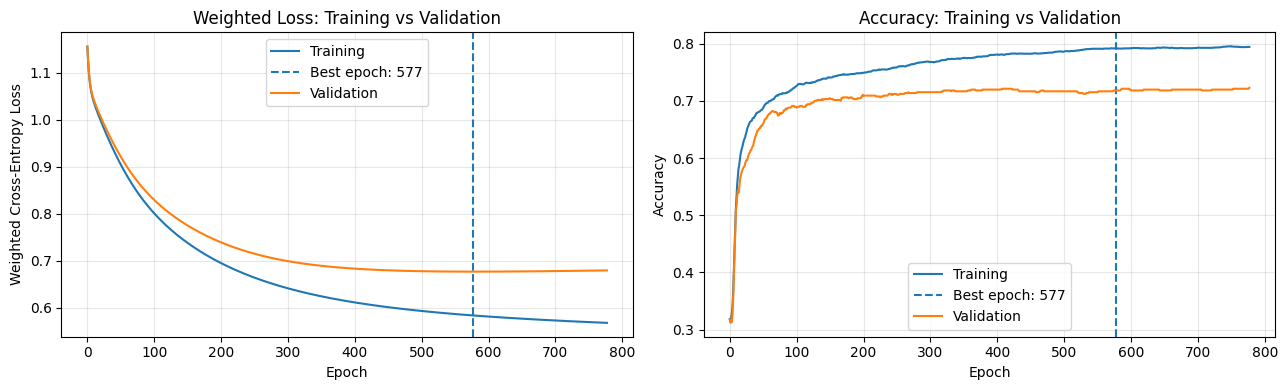

In [30]:
# ---------------------------------------------------------
# Plot training history
# ---------------------------------------------------------

train_losses = history_sigmoid["train_loss"]
validation_losses = history_sigmoid["validation_loss"]

train_accuracies = history_sigmoid["train_accuracy"]
validation_accuracies = history_sigmoid["validation_accuracy"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves
axes[0].plot(train_losses, label="Training")
axes[0].axvline(
    best_epoch_sigmoid,
    linestyle="--",
    label=f"Best epoch: {best_epoch_sigmoid}"
)
axes[0].plot(validation_losses, label="Validation")

axes[0].set_title("Weighted Loss: Training vs Validation")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted Cross-Entropy Loss")

axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(train_accuracies, label="Training")
axes[1].axvline(
    best_epoch_sigmoid,
    linestyle="--",
    label=f"Best epoch: {best_epoch_sigmoid}"
)
axes[1].plot(validation_accuracies, label="Validation")

axes[1].set_title("Accuracy: Training vs Validation")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [31]:
# ---------------------------------------------------------
# Sigmoid validation evaluation
# ---------------------------------------------------------

sigmoid_val_probabilities = predict_probabilities(
    X_val,
    W1_sigmoid,
    b1_sigmoid,
    W2_sigmoid,
    b2_sigmoid
)

sigmoid_val_predictions = np.argmax(
    sigmoid_val_probabilities,
    axis=1
)

y_val_onehot = one_hot(
    y_val,
    NUM_CLASSES
)

sigmoid_val_unweighted_loss = compute_loss(
    y_val_onehot,
    sigmoid_val_probabilities,
    class_weights=None
)

sigmoid_val_weighted_loss = compute_loss(
    y_val_onehot,
    sigmoid_val_probabilities,
    class_weights=class_weights
)

sigmoid_val_metrics = calculate_multiclass_metrics(
    y_val,
    sigmoid_val_predictions,
    NUM_CLASSES
)

print("Sigmoid validation results")
print(
    f"Unweighted loss:  "
    f"{sigmoid_val_unweighted_loss:.4f}"
)
print(
    f"Weighted loss:    "
    f"{sigmoid_val_weighted_loss:.4f}"
)
print(
    f"Accuracy:         "
    f"{sigmoid_val_metrics['accuracy']:.2%}"
)
print(
    f"Balanced accuracy:"
    f" {sigmoid_val_metrics['balanced_accuracy']:.2%}"
)
print(
    f"Macro F1:         "
    f"{sigmoid_val_metrics['macro_f1']:.4f}"
)
print(
    f"Weighted F1:      "
    f"{sigmoid_val_metrics['weighted_f1']:.4f}"
)


Sigmoid validation results
Unweighted loss:  0.6363
Weighted loss:    0.6772
Accuracy:         71.84%
Balanced accuracy: 68.32%
Macro F1:         0.6754
Weighted F1:      0.7299


### Conclusion – Learning Curves

The learning curves indicate that both training and validation losses decreased steadily before stabilizing. Early stopping effectively limited overfitting by selecting the model from the epoch with the best validation performance.

## 32. Reduce the Hidden-Layer Size

The initial network uses 20 hidden neurons.

A second Sigmoid network with only 8 hidden neurons is trained to investigate whether a smaller network provides similar or improved validation performance.

Reducing the number of hidden neurons decreases the number of trainable parameters and may improve generalization by reducing model complexity.

In [32]:
HIDDEN_SIZE = 8

In [33]:
(
    W1_sigmoid,
    b1_sigmoid,
    W2_sigmoid,
    b2_sigmoid,
    history_sigmoid,
    best_epoch_sigmoid
) = train(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    num_classes=NUM_CLASSES,
    hidden_size=HIDDEN_SIZE,
    class_weights=class_weights,
    epochs=3000,
    learning_rate=0.1,
    patience=200,
    minimum_improvement=1e-5,
    seed=42,
    verbose=True
)

Epoch    0 | Train Loss: 1.1384 | Train Accuracy: 31.78% | Val Loss: 1.1317 | Val Accuracy: 32.23%
Epoch  100 | Train Loss: 0.9282 | Train Accuracy: 68.48% | Val Loss: 0.9437 | Val Accuracy: 65.81%
Epoch  200 | Train Loss: 0.7638 | Train Accuracy: 74.29% | Val Loss: 0.8039 | Val Accuracy: 69.43%
Epoch  300 | Train Loss: 0.6842 | Train Accuracy: 76.10% | Val Loss: 0.7402 | Val Accuracy: 69.73%
Epoch  400 | Train Loss: 0.6395 | Train Accuracy: 77.42% | Val Loss: 0.7058 | Val Accuracy: 70.48%
Epoch  500 | Train Loss: 0.6129 | Train Accuracy: 78.26% | Val Loss: 0.6900 | Val Accuracy: 70.78%
Epoch  600 | Train Loss: 0.5960 | Train Accuracy: 78.59% | Val Loss: 0.6839 | Val Accuracy: 71.23%
Epoch  700 | Train Loss: 0.5842 | Train Accuracy: 78.65% | Val Loss: 0.6822 | Val Accuracy: 71.99%
Epoch  800 | Train Loss: 0.5756 | Train Accuracy: 78.91% | Val Loss: 0.6828 | Val Accuracy: 71.54%
Epoch  900 | Train Loss: 0.5688 | Train Accuracy: 79.13% | Val Loss: 0.6846 | Val Accuracy: 71.69%

Early sto

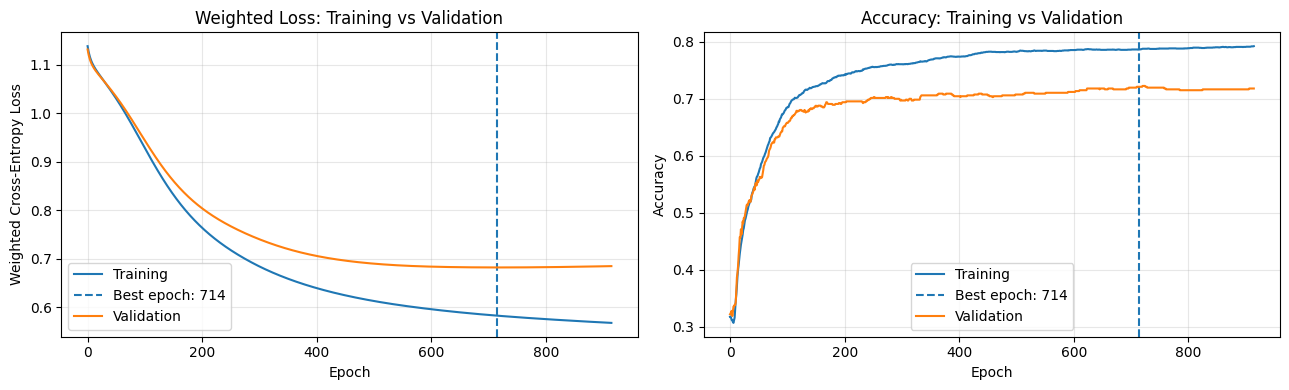

In [34]:
# ---------------------------------------------------------
# Plot training history
# ---------------------------------------------------------

train_losses = history_sigmoid["train_loss"]
validation_losses = history_sigmoid["validation_loss"]

train_accuracies = history_sigmoid["train_accuracy"]
validation_accuracies = history_sigmoid["validation_accuracy"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves
axes[0].plot(train_losses, label="Training")
axes[0].axvline(
    best_epoch_sigmoid,
    linestyle="--",
    label=f"Best epoch: {best_epoch_sigmoid}"
)
axes[0].plot(validation_losses, label="Validation")

axes[0].set_title("Weighted Loss: Training vs Validation")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted Cross-Entropy Loss")

axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(train_accuracies, label="Training")
axes[1].axvline(
    best_epoch_sigmoid,
    linestyle="--",
    label=f"Best epoch: {best_epoch_sigmoid}"
)
axes[1].plot(validation_accuracies, label="Validation")

axes[1].set_title("Accuracy: Training vs Validation")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# ---------------------------------------------------------
# Sigmoid validation evaluation
# ---------------------------------------------------------

sigmoid_val_probabilities = predict_probabilities(
    X_val,
    W1_sigmoid,
    b1_sigmoid,
    W2_sigmoid,
    b2_sigmoid
)

sigmoid_val_predictions = np.argmax(
    sigmoid_val_probabilities,
    axis=1
)

y_val_onehot = one_hot(
    y_val,
    NUM_CLASSES
)

sigmoid_val_unweighted_loss = compute_loss(
    y_val_onehot,
    sigmoid_val_probabilities,
    class_weights=None
)

sigmoid_val_weighted_loss = compute_loss(
    y_val_onehot,
    sigmoid_val_probabilities,
    class_weights=class_weights
)

sigmoid_val_metrics = calculate_multiclass_metrics(
    y_val,
    sigmoid_val_predictions,
    NUM_CLASSES
)

print("Sigmoid validation results")
print(
    f"Unweighted loss:  "
    f"{sigmoid_val_unweighted_loss:.4f}"
)
print(
    f"Weighted loss:    "
    f"{sigmoid_val_weighted_loss:.4f}"
)
print(
    f"Accuracy:         "
    f"{sigmoid_val_metrics['accuracy']:.2%}"
)
print(
    f"Balanced accuracy:"
    f" {sigmoid_val_metrics['balanced_accuracy']:.2%}"
)
print(
    f"Macro F1:         "
    f"{sigmoid_val_metrics['macro_f1']:.4f}"
)
print(
    f"Weighted F1:      "
    f"{sigmoid_val_metrics['weighted_f1']:.4f}"
)


Sigmoid validation results
Unweighted loss:  0.6397
Weighted loss:    0.6822
Accuracy:         72.14%
Balanced accuracy: 68.16%
Macro F1:         0.6755
Weighted F1:      0.7313


### **Conclusion – Hidden-Layer Size**

The 20-neuron network achieved a slightly lower weighted validation loss, while the 8-neuron network produced broadly similar classification performance using substantially fewer trainable parameters.
The 8-neuron architecture was therefore retained as a reduced-capacity model for the activation-function comparison. This selection represents a trade-off between predictive performance and model complexity rather than an absolute improvement in validation loss.

### Sigmoid Validation Classification Report

Per-class precision, recall, F1, and support for the Sigmoid model on the validation set, built from the metrics already calculated above.


In [36]:
sigmoid_val_report_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": (
        sigmoid_val_metrics[
            "precision_per_class"
        ]
    ),
    "Recall": (
        sigmoid_val_metrics[
            "recall_per_class"
        ]
    ),
    "F1": (
        sigmoid_val_metrics[
            "f1_per_class"
        ]
    ),
    "Support": (
        sigmoid_val_metrics[
            "support_per_class"
        ]
    )
}).set_index("Class")

sigmoid_val_report_df.round(3)


,Precision,Recall,F1,Support
Class,,,,
Dropout,0.788,0.732,0.759,213
Enrolled,0.399,0.529,0.455,119
Graduate,0.844,0.783,0.812,332


### **Conclusion – Sigmoid Model Evaluation**

The Sigmoid neural network (HIDDEN_SIZE = 8) achieved reasonable validation performance across the three outcome classes. The model performed most strongly for Graduate and Dropout students, while Enrolled remained the most difficult class.
These results were obtained from the validation set and are used for model comparison only. The test set remains untouched at this stage.

## 33. Introduce the ReLU Experiment

To compare the effect of different activation functions, a second neural network is trained using the Rectified Linear Unit (ReLU) activation function while keeping the remaining architecture unchanged.

The following components remain identical to the Sigmoid model:

- training, validation, and test datasets;
- network architecture (one hidden layer with 8 neurons);
- softmax output layer;
- weighted cross-entropy loss;
- inverse-frequency class weights;
- learning rate;
- early stopping strategy.

Only the hidden-layer activation function and its derivative are changed. This allows a fair comparison of the effect of the activation function on classification performance.


## 34. Define the ReLU Activation Function

The Rectified Linear Unit (ReLU) is defined as

$$
\mathrm{ReLU}(z)=\max(0,z)
$$

Unlike the sigmoid function, ReLU does not compress positive values into the interval \((0,1)\). Instead:

- negative inputs become 0;
- positive inputs remain unchanged.

This reduces the vanishing-gradient problem and often allows neural networks to learn faster, particularly in deeper architectures.

The derivative of ReLU is

$$
\mathrm{ReLU}'(z)=
\begin{cases}
1, & z>0 \\
0, & z\le0
\end{cases}
$$

During backpropagation, neurons with positive activation continue to update their weights, while neurons receiving negative inputs produce zero gradients.

In [37]:
def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)


## 37. Train the Neural Network Using ReLU

Forward propagation changes only the hidden-layer activation:

$$
Z_1=XW_1+b_1
$$

$$
A_1=\mathrm{ReLU}(Z_1)
$$

The output layer remains unchanged:

$$
Z_2=A_1W_2+b_2
$$

$$
A_2=\mathrm{Softmax}(Z_2)
$$

Backpropagation follows the same procedure as the Sigmoid model, except that the derivative of ReLU is used when computing the hidden-layer gradients.

The model is trained using the same early-stopping strategy, class weights, and hyperparameters to ensure that any performance difference is due only to the activation function.

In [38]:
def forward_relu(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = softmax(z2)

    return z1, a1, z2, a2

In [39]:
def backward_relu(X, y_true_onehot, z1, a1, a2, W2, class_weights=None):
    number_of_samples = X.shape[0]

    if class_weights is None:
        normalizer = number_of_samples

        d_output = (a2 - y_true_onehot) / normalizer

    else:
        sample_weights = (y_true_onehot @ class_weights).reshape(-1, 1)

        normalizer = np.sum(sample_weights)

        d_output = (sample_weights * (a2 - y_true_onehot)) / normalizer

    dW2 = a1.T @ d_output

    db2 = np.sum(d_output, axis=0, keepdims=True)

    hidden_error = d_output @ W2.T

    d_hidden = hidden_error * relu_derivative(z1)

    dW1 = X.T @ d_hidden

    db1 = np.sum(d_hidden, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


In [40]:
def predict_probabilities_relu(X, W1, b1, W2, b2):
    _, _, _, probabilities = forward_relu(X, W1, b1, W2, b2)

    return probabilities


def predict_relu(X, W1, b1, W2, b2):
    probabilities = predict_probabilities_relu(X, W1, b1, W2, b2)

    return np.argmax(probabilities, axis=1)


In [41]:
def train_relu(
    X_train,
    y_train,
    X_val,
    y_val,
    num_classes,
    hidden_size,
    class_weights=None,
    epochs=3000,
    learning_rate=0.1,
    patience=200,
    minimum_improvement=1e-5,
    seed=42,
    verbose=True,
):
    input_size = X_train.shape[1]
    print(f"Hidden Size: {hidden_size}")

    W1, b1, W2, b2 = init_params(input_size, hidden_size, num_classes, seed=seed)

    y_train_onehot = one_hot(y_train, num_classes)

    y_val_onehot = one_hot(y_val, num_classes)

    history = {
        "train_loss": [],
        "validation_loss": [],
        "train_accuracy": [],
        "validation_accuracy": [],
    }

    best_validation_loss = np.inf
    best_epoch = 0
    best_parameters = None
    epochs_without_improvement = 0

    for epoch in range(epochs):

        # Forward pass with ReLU
        z1, a1, z2, train_probabilities = forward_relu(X_train, W1, b1, W2, b2)

        train_loss = compute_loss(y_train_onehot, train_probabilities, class_weights)

        train_predictions = np.argmax(train_probabilities, axis=1)

        train_accuracy = np.mean(train_predictions == y_train)

        # Validation
        validation_probabilities = predict_probabilities_relu(X_val, W1, b1, W2, b2)

        validation_loss = compute_loss(
            y_val_onehot, validation_probabilities, class_weights
        )

        validation_predictions = np.argmax(validation_probabilities, axis=1)

        validation_accuracy = np.mean(validation_predictions == y_val)

        history["train_loss"].append(train_loss)
        history["validation_loss"].append(validation_loss)
        history["train_accuracy"].append(train_accuracy)
        history["validation_accuracy"].append(validation_accuracy)

        # Save best model
        if validation_loss < (best_validation_loss - minimum_improvement):
            best_validation_loss = validation_loss
            best_epoch = epoch

            best_parameters = (W1.copy(), b1.copy(), W2.copy(), b2.copy())

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        # Backpropagation with ReLU derivative
        dW1, db1, dW2, db2 = backward_relu(
            X_train, y_train_onehot, z1, a1, train_probabilities, W2, class_weights
        )

        W1, b1, W2, b2 = update_params(
            W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate
        )

        if verbose and epoch % 100 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Accuracy: {train_accuracy:.2%} | "
                f"Val Loss: {validation_loss:.4f} | "
                f"Val Accuracy: {validation_accuracy:.2%}"
            )

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    W1, b1, W2, b2 = best_parameters

    print(f"Best ReLU validation epoch: {best_epoch}")
    print(f"Best weighted ReLU validation loss: " f"{best_validation_loss:.4f}")

    return (W1, b1, W2, b2, history, best_epoch)


In [42]:
(
    W1_relu,
    b1_relu,
    W2_relu,
    b2_relu,
    history_relu,
    best_epoch_relu
) = train_relu(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    num_classes=NUM_CLASSES,
    hidden_size=8,
    class_weights=class_weights,
    epochs=3000,
    learning_rate=0.1,
    patience=200,
    minimum_improvement=1e-5,
    seed=42,
    verbose=True
)

Hidden Size: 8
Epoch    0 | Train Loss: 1.1789 | Train Accuracy: 31.85% | Val Loss: 1.1695 | Val Accuracy: 31.17%
Epoch  100 | Train Loss: 0.6447 | Train Accuracy: 76.87% | Val Loss: 0.7408 | Val Accuracy: 71.39%
Epoch  200 | Train Loss: 0.5535 | Train Accuracy: 80.23% | Val Loss: 0.7102 | Val Accuracy: 72.14%
Epoch  300 | Train Loss: 0.5159 | Train Accuracy: 81.43% | Val Loss: 0.7252 | Val Accuracy: 71.69%

Early stopping at epoch 386.
Best ReLU validation epoch: 186
Best weighted ReLU validation loss: 0.7096


## 35. Evaluate the ReLU Model on the Validation Set

The best ReLU parameters restored through early stopping are evaluated on the validation set. The resulting validation loss, accuracy, balanced accuracy, macro F1, and weighted F1 are compared with the corresponding Sigmoid validation results. The test set is not used during this comparison.

In [43]:
# ---------------------------------------------------------
# ReLU validation evaluation
# ---------------------------------------------------------

relu_val_probabilities = predict_probabilities_relu(
    X_val,
    W1_relu,
    b1_relu,
    W2_relu,
    b2_relu
)

relu_val_predictions = np.argmax(
    relu_val_probabilities,
    axis=1
)

relu_val_unweighted_loss = compute_loss(
    y_val_onehot,
    relu_val_probabilities,
    class_weights=None
)

relu_val_weighted_loss = compute_loss(
    y_val_onehot,
    relu_val_probabilities,
    class_weights=class_weights
)

relu_val_metrics = calculate_multiclass_metrics(
    y_val,
    relu_val_predictions,
    NUM_CLASSES
)

print("ReLU validation results")
print(
    f"Unweighted loss:  "
    f"{relu_val_unweighted_loss:.4f}"
)
print(
    f"Weighted loss:    "
    f"{relu_val_weighted_loss:.4f}"
)
print(
    f"Accuracy:         "
    f"{relu_val_metrics['accuracy']:.2%}"
)
print(
    f"Balanced accuracy:"
    f" {relu_val_metrics['balanced_accuracy']:.2%}"
)
print(
    f"Macro F1:         "
    f"{relu_val_metrics['macro_f1']:.4f}"
)
print(
    f"Weighted F1:      "
    f"{relu_val_metrics['weighted_f1']:.4f}"
)

ReLU validation results
Unweighted loss:  0.6576
Weighted loss:    0.7096
Accuracy:         71.99%
Balanced accuracy: 68.61%
Macro F1:         0.6794
Weighted F1:      0.7322


## 36. Compare Sigmoid and ReLU

Sigmoid and ReLU are compared using the same training and validation partitions, hidden-layer size, class weights, learning rate, early-stopping settings, and random seed.
The comparison uses validation loss, validation accuracy, balanced accuracy, macro F1, weighted F1, and convergence speed. The test dataset is reserved for the final evaluation of the selected activation function.

In [44]:
validation_comparison_df = pd.DataFrame({
    "Activation": [
        "Sigmoid",
        "ReLU"
    ],
    "Best Epoch": [
        best_epoch_sigmoid,
        best_epoch_relu
    ],
    "Unweighted Validation Loss": [
        sigmoid_val_unweighted_loss,
        relu_val_unweighted_loss
    ],
    "Weighted Validation Loss": [
        sigmoid_val_weighted_loss,
        relu_val_weighted_loss
    ],
    "Validation Accuracy": [
        sigmoid_val_metrics["accuracy"],
        relu_val_metrics["accuracy"]
    ],
    "Balanced Accuracy": [
        sigmoid_val_metrics["balanced_accuracy"],
        relu_val_metrics["balanced_accuracy"]
    ],
    "Macro F1": [
        sigmoid_val_metrics["macro_f1"],
        relu_val_metrics["macro_f1"]
    ],
    "Weighted F1": [
        sigmoid_val_metrics["weighted_f1"],
        relu_val_metrics["weighted_f1"]
    ]
})

validation_comparison_df

,Activation,Best Epoch,Unweighted Validation Loss,Weighted Validation Loss,Validation Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Sigmoid,714,0.639736,0.682204,0.721386,0.681646,0.675499,0.731285
1,ReLU,186,0.657623,0.709648,0.719880,0.686148,0.679396,0.732220


### Conclusion – Comparison of Sigmoid and ReLU on the Validation Set

The comparison shows that both activation functions produce very similar validation performance, although each has different strengths.

- The **Sigmoid model** achieves a lower **unweighted validation loss (0.6397)** and **weighted validation loss (0.6822)** than the ReLU model. Lower loss values indicate that the predicted probability distributions are closer to the true class labels.

- The **ReLU model** achieves slightly higher **Balanced Accuracy (68.61%)**, **Macro F1 Score (0.6794)**, and **Weighted F1 Score (0.7322)** than the Sigmoid model. These metrics indicate a marginal improvement in overall classification performance across all three classes, particularly in an imbalanced classification problem where equal consideration is given to minority classes.

- The overall **validation accuracy** is almost identical for both models (72.14% for Sigmoid and 71.99% for ReLU), with a difference of only approximately **0.15 percentage points**, indicating that both activation functions classify a similar proportion of validation observations correctly.

- A notable difference is the **training efficiency**. The ReLU model reached its best validation performance after only **186 epochs**, whereas the Sigmoid model required **714 epochs**. This demonstrates that ReLU converges substantially faster, requiring fewer training iterations to achieve its optimal validation performance.

Overall, the comparison indicates that neither activation function is overwhelmingly superior. The Sigmoid model achieves better lower validation loss, while the ReLU model demonstrates slightly stronger classification metrics and significantly faster convergence.

For an imbalanced multi-class classification problem, Macro F1 and Balanced Accuracy are generally more informative than overall accuracy. Hence we are choosing ReLU as the final model despite slightly higher loss values.

## 37. Select the Final Neural Network Model

After comparing the Sigmoid and ReLU neural networks using the **validation dataset**, the ReLU model is selected as the final model for evaluation.

The parameters corresponding to the best-performing ReLU model are assigned as the final network parameters:

- \(W_1\) – weights connecting the input layer to the hidden layer;
- \(b_1\) – hidden-layer bias vector;
- \(W_2\) – weights connecting the hidden layer to the output layer;
- \(b_2\) – output-layer bias vector.

These parameters were obtained from the epoch that achieved the **lowest validation loss** during training through the early stopping procedure.

No additional learning takes place in this step. The trained ReLU parameters are simply designated as the final model that will be used for prediction.



In [45]:
W1_final = W1_relu
b1_final = b1_relu
W2_final = W2_relu
b2_final = b2_relu

In [46]:
# ---------------------------------------------------------
# Final ReLU evaluation on untouched test data
# ---------------------------------------------------------

final_test_probabilities = predict_probabilities_relu(
    X_test,
    W1_final,
    b1_final,
    W2_final,
    b2_final
)

final_test_predictions = np.argmax(
    final_test_probabilities,
    axis=1
)

y_test_onehot = one_hot(
    y_test,
    NUM_CLASSES
)

final_test_unweighted_loss = compute_loss(
    y_test_onehot,
    final_test_probabilities,
    class_weights=None
)

final_test_weighted_loss = compute_loss(
    y_test_onehot,
    final_test_probabilities,
    class_weights=class_weights
)

final_test_metrics = calculate_multiclass_metrics(
    y_test,
    final_test_predictions,
    NUM_CLASSES
)

print("Final ReLU test results")
print(
    f"Unweighted test loss: "
    f"{final_test_unweighted_loss:.4f}"
)
print(
    f"Weighted test loss:   "
    f"{final_test_weighted_loss:.4f}"
)
print(
    f"Test accuracy:        "
    f"{final_test_metrics['accuracy']:.2%}"
)
print(
    f"Balanced accuracy:    "
    f"{final_test_metrics['balanced_accuracy']:.2%}"
)
print(
    f"Macro F1:             "
    f"{final_test_metrics['macro_f1']:.4f}"
)
print(
    f"Weighted F1:          "
    f"{final_test_metrics['weighted_f1']:.4f}"
)

Final ReLU test results
Unweighted test loss: 0.6553
Weighted test loss:   0.6994
Test accuracy:        72.14%
Balanced accuracy:    69.45%
Macro F1:             0.6841
Weighted F1:          0.7336


## 38. Evaluate the Final ReLU Model on the Test Set

In [47]:
relu_test_report_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": (
        final_test_metrics[
            "precision_per_class"
        ]
    ),
    "Recall": (
        final_test_metrics[
            "recall_per_class"
        ]
    ),
    "F1": (
        final_test_metrics[
            "f1_per_class"
        ]
    ),
    "Support": (
        final_test_metrics[
            "support_per_class"
        ]
    )
}).set_index("Class")

relu_test_report_df.round(3)

,Precision,Recall,F1,Support
Class,,,,
Dropout,0.815,0.704,0.756,213
Enrolled,0.411,0.605,0.490,119
Graduate,0.843,0.774,0.807,332


## 39. Final Test Confusion Matrix

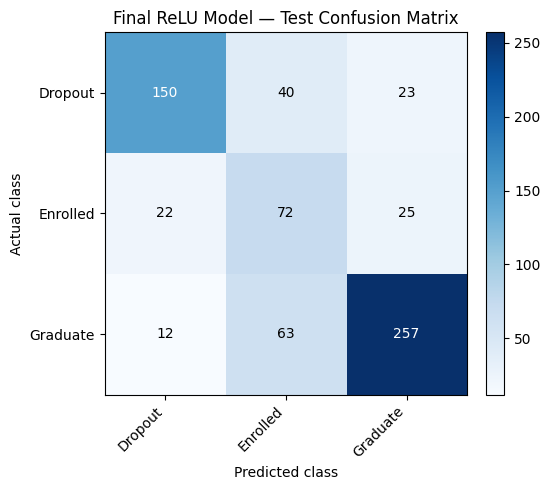

[[150  40  23]
 [ 22  72  25]
 [ 12  63 257]]


In [48]:
# ---------------------------------------------------------
# Final ReLU test confusion matrix
# ---------------------------------------------------------

final_relu_cm = np.zeros(
    (NUM_CLASSES, NUM_CLASSES),
    dtype=int
)

for actual_class, predicted_class in zip(
    y_test,
    final_test_predictions
):
    final_relu_cm[
        actual_class,
        predicted_class
    ] += 1

fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(
    final_relu_cm,
    cmap="Blues"
)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(CLASS_NAMES)

ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title(
    "Final ReLU Model — Test Confusion Matrix"
)

threshold = final_relu_cm.max() / 2

for row in range(NUM_CLASSES):
    for column in range(NUM_CLASSES):
        ax.text(
            column,
            row,
            final_relu_cm[row, column],
            ha="center",
            va="center",
            color=(
                "white"
                if final_relu_cm[row, column] > threshold
                else "black"
            )
        )

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()
plt.show()

print(final_relu_cm)

## 40. Interpret the Final Results


#### Dropout

| Metric | Value |
|--------|------:|
| Precision | 0.815 |
| Recall | 0.704 |
| F1 Score | 0.756 |
| Support | 213 |

The model performs well when identifying students who eventually **drop out**.

A precision of **81.5%** indicates that when the model predicts a student will drop out, the prediction is correct most of the time. This means relatively few Graduate or Enrolled students are incorrectly classified as Dropout.

The recall of **70.4%** shows that approximately seven out of every ten actual dropout students are correctly identified. The remaining students are incorrectly classified as either Enrolled or Graduate.

The F1 score of **0.756** indicates a good balance between precision and recall, demonstrating that the model is effective at detecting students at risk of dropping out.

---

#### Enrolled

| Metric | Value |
|--------|------:|
| Precision | 0.411 |
| Recall | 0.605 |
| F1 Score | 0.490 |
| Support | 119 |

The **Enrolled** class is the most difficult class for the neural network to predict.

Of all instances that the model predicted as "Enrolled", only 41.1% were actually Enrolled.

However, the recall of **60.5%** indicates that the model successfully identifies approximately six out of every ten students who are genuinely still enrolled.

The lower F1 score (**0.490**) reflects the challenge of distinguishing Enrolled students from the other two classes. This is expected because Enrolled students often share characteristics with both students who eventually graduate and students who eventually drop out.


---

#### Graduate

| Metric | Value |
|--------|------:|
| Precision | 0.843 |
| Recall | 0.774 |
| F1 Score | 0.807 |
| Support | 332 |

The model performs best when predicting **Graduate** students.

A precision of **84.3%** indicates that most students predicted as Graduates are correctly classified.

The recall of **77.4%** shows that the majority of actual Graduate students are successfully identified.

The F1 score of **0.807**, the highest among the three classes, demonstrates that the model consistently distinguishes Graduate students from the other two categories.

This strong performance is consistent with the exploratory data analysis, which showed that academic performance variables—particularly semester grades and approval rates—clearly separate Graduate students from the other outcomes.

---

### Overall Interpretation

The final ReLU neural network demonstrates good predictive performance across the three student outcomes.

The model performs strongest for the **Graduate** class, followed closely by the **Dropout** class. These two groups exhibit clearer academic patterns, allowing the neural network to distinguish them with relatively high precision and recall.

The **Enrolled** class remains the most challenging to predict. Because these students have not yet reached a final academic outcome, their characteristics overlap with both future graduates and future dropouts. As a result, the model produces more false-positive predictions for this class, leading to lower precision and a lower overall F1 score.

Overall, the results indicate that the neural network successfully captures the underlying relationships between student characteristics and academic outcomes. The model is particularly effective at identifying students who are likely to graduate or drop out, while providing reasonable, although less accurate, predictions for students who remain enrolled.

## 41. Final Conclusion

This study developed and evaluated a multi-class Artificial Neural Network (ANN) to predict student academic outcomes as **Dropout**, **Enrolled**, or **Graduate** using demographic, socio-economic, and academic performance variables.

The project followed a complete supervised machine learning workflow beginning with exploratory data analysis, feature engineering, data preprocessing, neural network implementation from scratch, model training, validation, and final evaluation.

Exploratory Data Analysis showed that academic performance variables, particularly first- and second-semester grades, approval rates exhibited the strongest relationship with the final student outcome. In contrast, demographic variables showed comparatively weaker predictive power.

Feature engineering improved the representation of student academic progress by creating normalized curriculum-based variables, including first- and second-semester approval rates and evaluations per enrolled unit. These engineered features provided more meaningful measures of academic success and participation than the original raw course counts.

Categorical variables were transformed using one-hot encoding, while numerical variables were standardized using statistics calculated only from the training dataset to prevent information leakage. Class imbalance was addressed using inverse-frequency class weights, allowing the neural network to place greater emphasis on the minority **Enrolled** class during training.

Two hidden-layer activation functions, **Sigmoid** and **ReLU**, were evaluated using identical training, validation. The comparison demonstrated that both activation functions achieved similar validation performance. The Sigmoid network produced lower validation loss, whereas the ReLU network achieved marginally higher Balanced Accuracy, Macro F1 Score, and Weighted F1 Score while converging substantially faster.

Based on the validation results, the **ReLU activation function** was selected as the final model because it provided slightly stronger classification performance across all classes while requiring significantly fewer training epochs. The selected model was then evaluated once on the untouched test dataset to obtain an unbiased estimate of its generalization performance.

The final classification report showed that the neural network performed best when identifying **Graduate** students, followed by **Dropout** students. The **Enrolled** class remained the most challenging because its characteristics overlap with both students who eventually graduate and those who later drop out. Although class weighting improved the model's ability to detect Enrolled students, this improvement came with a reduction in precision.

Overall, the results demonstrate that a carefully designed shallow neural network can effectively model student academic outcomes using structured educational data.

## 42. Future Work

Although the proposed neural network achieved good predictive performance, several opportunities exist for further improvement.

### 1. Hyperparameter Optimisation

The current model uses manually selected hyperparameters, including:

- hidden-layer size;
- learning rate;
- patience for early stopping;
- maximum number of training epochs.

Future work could perform systematic hyperparameter optimisation using Grid Search, Random Search, or Bayesian Optimisation to identify the optimal network configuration.

---

### 2. Deeper Neural Network Architectures

This study employed a shallow neural network with a single hidden layer.

Future research could investigate:

- multiple hidden layers;
- varying numbers of neurons;
- dropout regularisation;
- batch normalization.

These architectures may capture more complex nonlinear relationships within the student data.

---

### 3. Alternative Activation Functions

Only Sigmoid and ReLU activation functions were investigated.

Future experiments could compare additional activation functions such as:

- Leaky ReLU;
- ELU (Exponential Linear Unit);
- GELU (Gaussian Error Linear Unit);
- Swish.

These functions may improve convergence or classification performance.

---

### 4. Advanced Optimisation Algorithms

The current implementation uses standard gradient descent.

Performance may be improved by implementing adaptive optimisation algorithms such as:

- Momentum Gradient Descent;
- RMSProp;
- Adam;
- AdamW.

These optimizers generally provide faster convergence and greater stability during training.

---

### 5. Additional Feature Engineering

Further predictive information may be obtained by creating additional academic features, including:

- attendance consistency;
- credit completion rates;
- historical academic progression.

More informative features may improve the model's ability to distinguish the Enrolled class.

---

### 6. Improved Handling of Class Imbalance

Although inverse-frequency class weighting improved minority-class detection, additional imbalance-handling techniques could be explored, including:

- SMOTE (Synthetic Minority Oversampling Technique);
- Borderline-SMOTE;
- ADASYN;


These methods may further improve prediction of the Enrolled class.

---

### 7. Compare with Other Machine Learning Models

Future work could compare the neural network against other supervised learning algorithms, including:

- Logistic Regression;
- Decision Trees;
- Random Forest;
- Gradient Boosting;
- XGBoost;
- LightGBM.

Such comparisons would determine whether the neural network provides a significant advantage over traditional machine learning methods for this dataset.

---

### 8. Investigate Different Weight Initialization Techniques

In this study, both the Sigmoid and ReLU neural networks were initialized using the same scaled random initialization to ensure a fair comparison between the two activation functions. However, different activation functions often benefit from different initialization strategies.

Future work could investigate alternative weight initialization methods, including:

- **He Initialization**, which is specifically designed for ReLU-based networks and helps preserve gradient magnitudes during forward and backward propagation.


 Such experiments would provide a more comprehensive understanding of the interaction between activation functions and weight initialization in shallow neural networks.

---

